<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%B4%D1%8B%D2%9B_%D0%B6%D0%B5%D0%BB%D1%96%D0%BB%D0%B5%D1%80_%D0%BD%D0%B5%D0%B3%D1%96%D0%B7%D0%B4%D0%B5%D1%80%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Нейрондық желілер негіздері


## Мазмұны

1. Нейрондық желілерге кіріспе
2. Персептрон — ең қарапайым нейрон
3. Активация функциялары
4. Көпқабатты желі (MLP)
5. Тура таралу (Forward Propagation)
6. Кері таралу (Backward Propagation)



**Нұсқаулық:** Әрбір бөлімде теориялық түсіндірме, дайын мысал коды және орындауға арналған тапсырмалар бар. `# TODO` деп белгіленген жерлерді өз кодыңызбен толтырыңыз.

## Кітапханаларды жүктеу

Осы ноутбукта қолданылатын барлық кітапханаларды алдын ала жүктейміз.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# Matplotlib қазақша қаріптерге дайындық
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Барлық кітапханалар сәтті жүктелді.")

Барлық кітапханалар сәтті жүктелді.



# 1-бөлім. Нейрондық желілерге кіріспе

**Мақсат:** Биологиялық нейрон мен жасанды нейронның арасындағы байланысты түсіну, нейрондық желінің негізгі ұғымдарымен танысу.

---

## Теориялық негіз

Нейрондық желі (neural network) — адам миының жұмыс принципін математикалық түрде модельдейтін есептеу жүйесі. Адам миында шамамен 86 миллиард нейрон бар және олар бір-бірімен синапстар арқылы байланысқан.

Жасанды нейрон мына қадамдармен жұмыс істейді:

1. Кіріс мәндерін (x1, x2, ..., xn) қабылдайды
2. Әрбір кіріске салмақ (weight) береді: w1, w2, ..., wn
3. Олардың өлшенген қосындысын есептейді: z = w1*x1 + w2*x2 + ... + wn*xn + b
4. Активация функциясын қолданады: a = f(z)

Мұнда `b` — бос мүше (bias), ол нейронның «босатылу шегін» реттейді.

**Матрицалық түрде:** z = W * x + b

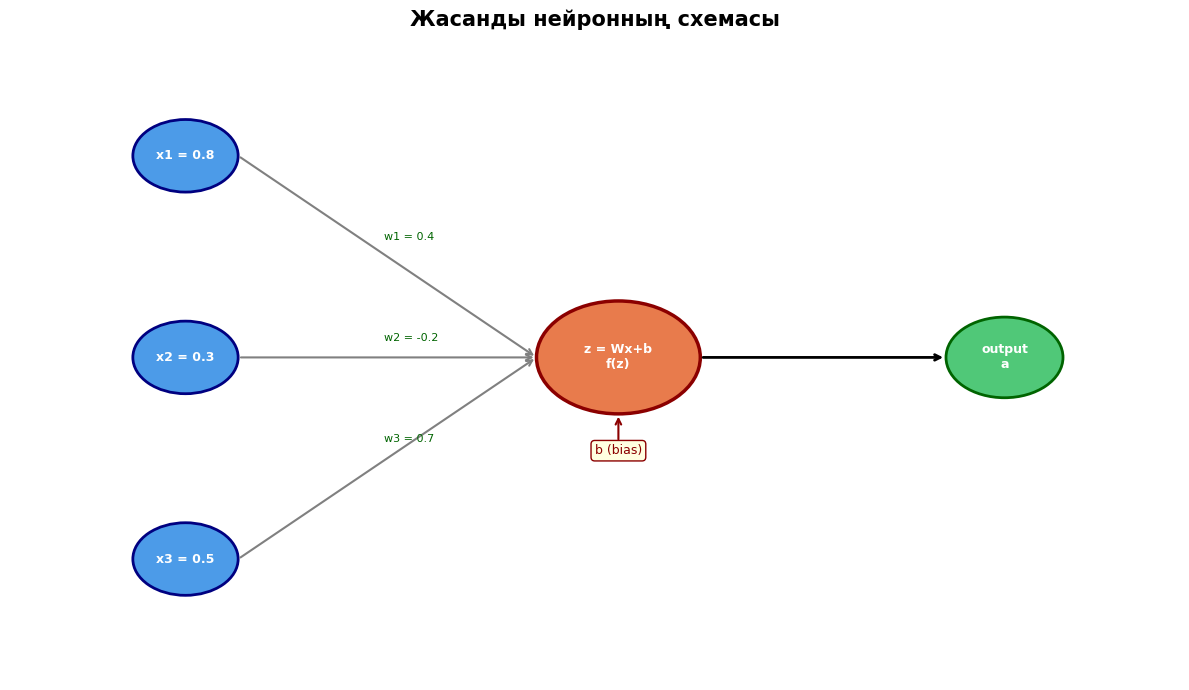

Нейрон схемасы салынды.


In [2]:
# Жасанды нейронның жұмысын визуализациялау

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title("Жасанды нейронның схемасы", fontsize=15, fontweight='bold')

# Кіріс нейрондары
inputs = [(1.5, 6.5), (1.5, 4.0), (1.5, 1.5)]
labels = ['x1 = 0.8', 'x2 = 0.3', 'x3 = 0.5']
weights = ['w1 = 0.4', 'w2 = -0.2', 'w3 = 0.7']

for i, ((x, y), lbl, w) in enumerate(zip(inputs, labels, weights)):
    circle = plt.Circle((x, y), 0.45, color='#4C9BE8', ec='navy', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, lbl, ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    # Байланыс сызығы
    ax.annotate('', xy=(4.5, 4.0), xytext=(x + 0.45, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text((x + 4.5) / 2 + 0.2, (y + 4.0) / 2 + 0.2, w, fontsize=8, color='darkgreen')

# Нейрон
neuron = plt.Circle((5.2, 4.0), 0.7, color='#E87B4C', ec='darkred', linewidth=2.5)
ax.add_patch(neuron)
ax.text(5.2, 4.0, 'z = Wx+b\nf(z)', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Шығыс
ax.annotate('', xy=(8.0, 4.0), xytext=(5.9, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
output_circle = plt.Circle((8.5, 4.0), 0.5, color='#50C878', ec='darkgreen', linewidth=2)
ax.add_patch(output_circle)
ax.text(8.5, 4.0, 'output\na', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Бос мүше белгісі
ax.text(5.2, 2.8, 'b (bias)', ha='center', fontsize=9, color='darkred',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='darkred'))
ax.annotate('', xy=(5.2, 3.3), xytext=(5.2, 2.95),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

plt.tight_layout()
plt.savefig('/tmp/neuron_schema.png', dpi=100, bbox_inches='tight')
plt.show()
print("Нейрон схемасы салынды.")

### Тапсырма 1.1 — Нейрон есебін қолмен есептеу

**Мақсат:** Нейронның математикалық есебін бастан аяқ өз бетіңізше орындап, нәтижені тексеру.

Берілген мәндер:
- Кірістер: x = [1.0, 2.0, 3.0]
- Салмақтар: w = [0.5, -0.3, 0.8]
- Бос мүше: b = 0.1

z = w1*x1 + w2*x2 + w3*x3 + b есептеңіз.

In [4]:
# Тапсырма 1.1
# Берілген мәндер
x = np.array([1.0, 2.0, 3.0])
w = np.array([0.5, -0.3, 0.8])
b = 0.1

# TODO: z мәнін есептеңіз (numpy dot өнімін немесе қосындыны қолданыңыз)
# Кеңес: numpy-де скалярлық көбейтінді np.dot(w, x) арқылы есептеледі
z = np.dot(w, x) + b

print(f"Кіріс векторы x: {x}")
print(f"Салмақ векторы w: {w}")
print(f"Бос мүше b: {b}")
print(f"Өлшенген қосынды z: {z:.4f}")

# Дұрыс жауап: z = 0.5*1 + (-0.3)*2 + 0.8*3 + 0.1 = 0.5 - 0.6 + 2.4 + 0.1 = 2.4
print(f"\nКүтілген жауап: 2.4")
print(f"Сіздің жауабыңыз дұрыс: {abs(z - 2.4) < 1e-9}")

Кіріс векторы x: [1. 2. 3.]
Салмақ векторы w: [ 0.5 -0.3  0.8]
Бос мүше b: 0.1
Өлшенген қосынды z: 2.4000

Күтілген жауап: 2.4
Сіздің жауабыңыз дұрыс: True


### Тапсырма 1.2 — Активация мәнін есептеу

**Мақсат:** z мәрінен алынған активацияны sigmoid және ReLU функциялары арқылы есептеу.

Жоғарыдағы 1.1 тапсырмасынан z = 2.4 мәнін қолданыңыз.

In [5]:
# Тапсырма 1.2
z_val = 2.4  # 1.1 тапсырмасынан

# TODO: sigmoid(z_val) есептеңіз
# Кеңес: sigmoid(z) = 1 / (1 + np.exp(-z))
sigmoid_out = 1 / (1 + np.exp(-z_val))

# TODO: relu(z_val) есептеңіз
# Кеңес: relu(z) = np.maximum(0, z)
relu_out = np.maximum(0, z)

print(f"z = {z_val}")
print(f"sigmoid(z) = {sigmoid_out:.4f}")
print(f"relu(z)    = {relu_out:.4f}")
# Күтілген: sigmoid ~ 0.9168, relu = 2.4


z = 2.4
sigmoid(z) = 0.9168
relu(z)    = 2.4000


### Тапсырма 1.3 — Бірнеше нейронды матрица түрінде есептеу

**Мақсат:** Бір қабаттағы 3 нейронның шығысын матрицалық операциямен бір уақытта есептеу.

Берілген: X пішіні (5, 4), W пішіні (4, 3), b пішіні (1, 3).

In [6]:
# Тапсырма 1.3
np.random.seed(7)
X_t13 = np.random.randn(5, 4)   # 5 үлгі, 4 белгі
W_t13 = np.random.randn(4, 3)   # 4 кіріс -> 3 нейрон
b_t13 = np.zeros((1, 3))        # bias

# TODO: Z = X_t13 @ W_t13 + b_t13  есептеңіз
# Кеңес: Python-да матрица көбейтіндісі @ операторымен жазылады
Z_t13 = X_t13 @ W_t13 + b_t13

# TODO: A = sigmoid(Z_t13) есептеңіз
A_t13 = 1 / (1 + np.exp(-Z_t13))

print(f"X пішіні: {X_t13.shape}")
print(f"W пішіні: {W_t13.shape}")
print(f"Z пішіні: {Z_t13.shape}  <- (5 үлгі, 3 нейрон)")
print(f"A пішіні: {A_t13.shape}")
print(f"A мәндері (алғашқы 2 үлгі):\n{A_t13[:2]}")


X пішіні: (5, 4)
W пішіні: (4, 3)
Z пішіні: (5, 3)  <- (5 үлгі, 3 нейрон)
A пішіні: (5, 3)
A мәндері (алғашқы 2 үлгі):
[[0.84052104 0.47610564 0.62080014]
 [0.36194658 0.76551579 0.17073932]]




# 2-бөлім. Персептрон

**Мақсат:** Персептронның жұмыс принципін, оқу алгоритмін және шектеулерін практика арқылы меңгеру.

---

## Теориялық негіз

Персептрон (perceptron) — 1958 жылы Фрэнк Розенблатт ұсынған ең алғашқы нейрондық желі моделі. Ол бинарлық жіктеу (binary classification) есептерін шешуге арналған.

**Персептронның жұмыс принципі:**

Шығыс мынадай анықталады:

```
y_pred = 1,  егер z >= 0
y_pred = 0,  егер z < 0
```

**Оқу ережесі (Perceptron Learning Rule):**

Қате болған жағдайда салмақтар жаңартылады:

```
w = w + lr * (y_true - y_pred) * x
b = b + lr * (y_true - y_pred)
```

мұнда `lr` — оқу жылдамдығы (learning rate).

**Персептронның шектеуі:** Ол тек сызықты ажыратылатын (linearly separable) деректерді жіктей алады. XOR есебін шеше алмайды — осы мәселені шешу үшін көпқабатты желілер ойлап табылды.

Персептрон дәлдігі (Accuracy): 100.0%


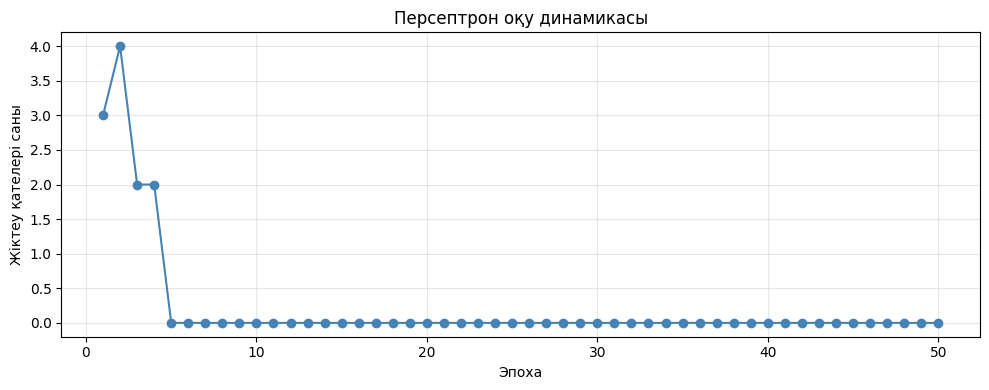

In [7]:
# Персептрон класын нуль деңгейден жазамыз

class Perceptron:
    """
    Қарапайым персептрон: бинарлық жіктеуші.
    """
    def __init__(self, learning_rate=0.1, n_epochs=100):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []

    def predict(self, X):
        """Баспалық (step) функция арқылы болжау жасайды."""
        z = np.dot(X, self.weights) + self.bias
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        """Персептронды оқытады."""
        n_samples, n_features = X.shape
        # Салмақтарды нольдермен инициализациялаймыз
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi.reshape(1, -1))[0]
                # Оқу ережесі
                update = self.lr * (yi - y_pred)
                self.weights += update * xi
                self.bias += update
                if update != 0:
                    errors += 1
            self.errors_per_epoch.append(errors)

        return self


# Iris деректер жиынынан 2 класты (setosa vs versicolor) аламыз
iris = load_iris()
# Тек алғашқы 2 белгіні және алғашқы 2 класты аламыз
X_iris = iris.data[:100, :2]   # sepal length, sepal width
y_iris = iris.target[:100]     # 0 = setosa, 1 = versicolor

# Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Персептронды оқытамыз
ppn = Perceptron(learning_rate=0.1, n_epochs=50)
ppn.fit(X_scaled, y_iris)

# Нәтижені тексерейік
y_pred = ppn.predict(X_scaled)
accuracy = accuracy_score(y_iris, y_pred)
print(f"Персептрон дәлдігі (Accuracy): {accuracy * 100:.1f}%")

# Қате саны эпохалар бойынша
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(ppn.errors_per_epoch) + 1), ppn.errors_per_epoch, marker='o', color='steelblue')
plt.xlabel("Эпоха")
plt.ylabel("Жіктеу қателері саны")
plt.title("Персептрон оқу динамикасы")
plt.tight_layout()
plt.show()

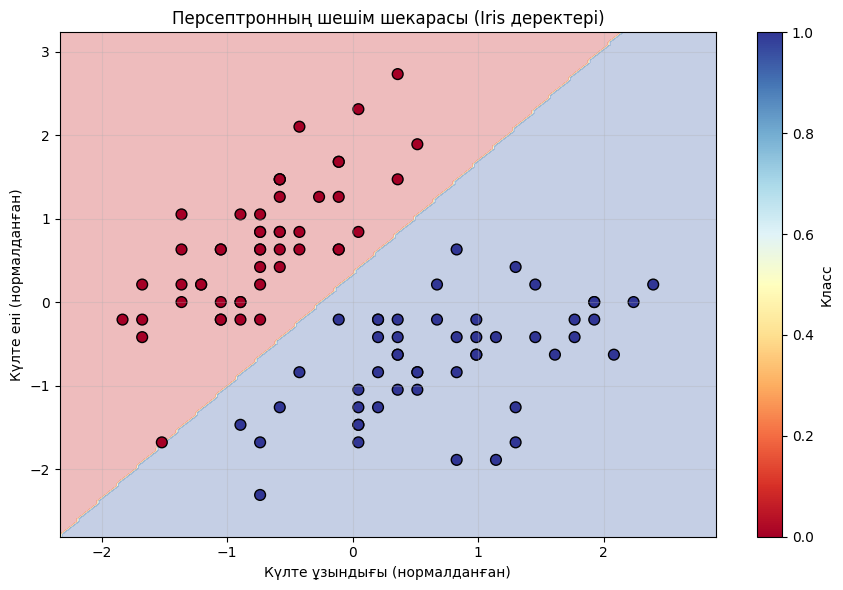

In [8]:
# Шешім шекарасын (decision boundary) визуализациялаймыз

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu',
                         edgecolors='black', s=60)
    ax.set_xlabel("Күлте ұзындығы (нормалданған)")
    ax.set_ylabel("Күлте ені (нормалданған)")
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='Класс')
    plt.tight_layout()
    plt.show()


plot_decision_boundary(ppn, X_scaled, y_iris, "Персептронның шешім шекарасы (Iris деректері)")

### Тапсырма 2.1 — Персептрон оқу жылдамдығының әсері

**Мақсат:** Оқу жылдамдығы (learning rate) параметрінің персептронның жинақталу жылдамдығына қалай әсер ететінін зерттеу.

Үш түрлі оқу жылдамдығын (0.001, 0.1, 1.0) салыстырыңыз.

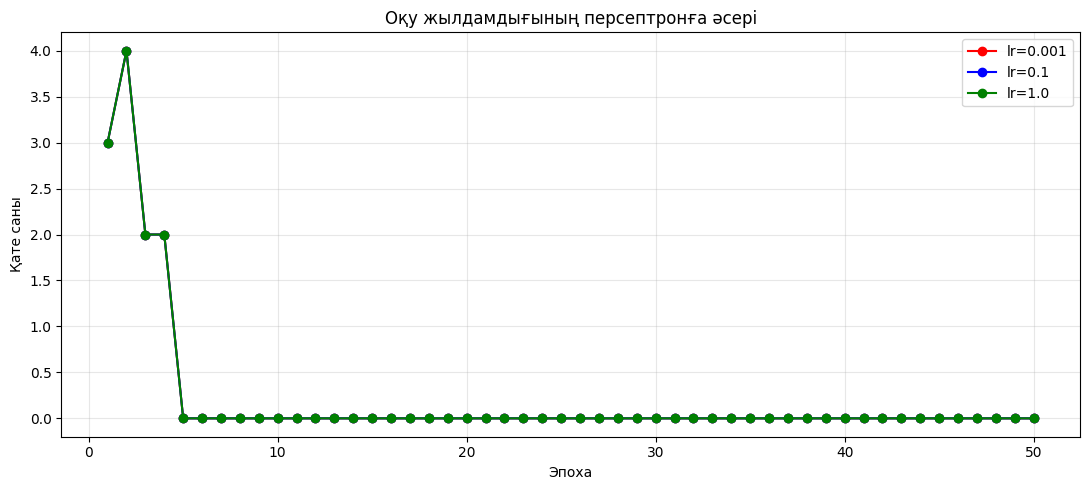

Жауабым: lr=0.1 ең тұрақты және жылдам жинақталды.


In [9]:
# Тапсырма 2.1
# Кеңес: жоғарыда жазылған Perceptron класын қолданыңыз,
# тек learning_rate параметрін өзгертіп, қате санын салыстырыңыз.

learning_rates = [0.001, 0.1, 1.0]
colors = ['red', 'blue', 'green']

plt.figure(figsize=(11, 5))

for lr, color in zip(learning_rates, colors):
    # TODO: Perceptron объектісін жасаңыз (lr=lr, n_epochs=50)
    model = Perceptron(learning_rate=lr, n_epochs=50)

    # TODO: Моделді X_scaled, y_iris мәліметтерімен оқытыңыз
    model.fit(X_scaled, y_iris)

    # TODO: Қате саны эпохалар бойынша сызыңыз (model.errors_per_epoch)
    plt.plot(
        range(1, len(model.errors_per_epoch) + 1),
        model.errors_per_epoch,
        color=color,
        marker='o',
        label=f"lr={lr}"
    )

plt.xlabel("Эпоха")
plt.ylabel("Қате саны")
plt.title("Оқу жылдамдығының персептронға әсері")
plt.legend([f"lr={lr}" for lr in learning_rates])
plt.tight_layout()
plt.show()

# TODO: Қайсы оқу жылдамдығы жақсырақ болды? Неліктен?
print("Жауабым: lr=0.1 ең тұрақты және жылдам жинақталды.")


### Тапсырма 2.2 — Персептронды Iris деректерінің барлық 4 белгісімен оқыту

**Мақсат:** 2 белгі орнына 4 белгіні қолданып, персептрон дәлдігінің өзгеруін бақылау.

In [10]:
# Тапсырма 2.2
# Iris: setosa (0) vs versicolor (1), бірақ енді 4 белгінің барлығын аламыз
iris_t22 = load_iris()
X_t22 = iris_t22.data[:100, :]   # 4 белгі
y_t22 = iris_t22.target[:100]

# TODO: X_t22 нормализациялаңыз (StandardScaler)
scaler_t22 = StandardScaler()
X_t22_scaled = scaler_t22.fit_transform(X_t22)

# TODO: Perceptron(learning_rate=0.1, n_epochs=50) жасаңыз және оқытыңыз
ppn_t22 = Perceptron(learning_rate=0.1, n_epochs=50)
ppn_t22.fit(X_t22_scaled, y_t22)

# TODO: Дәлдікті есептеп басып шығарыңыз
# Кеңес: accuracy_score(y_t22, ppn_t22.predict(X_t22_scaled))
acc_t22 = accuracy_score(y_t22, ppn_t22.predict(X_t22_scaled))
print(f"4 белгімен персептрон дәлдігі: {acc_t22 * 100:.1f}%")
# 2 белгімен алынған нәтижемен салыстырыңыз



4 белгімен персептрон дәлдігі: 100.0%
4 белгімен персептрон дәлдігі: 100.0%


### Тапсырма 2.3 — Персептронның салмақтарын визуализациялау

**Мақсат:** Оқытылған персептронның w1, w2 салмақтарының оқу барысындағы өзгеруін графикте бейнелеу.

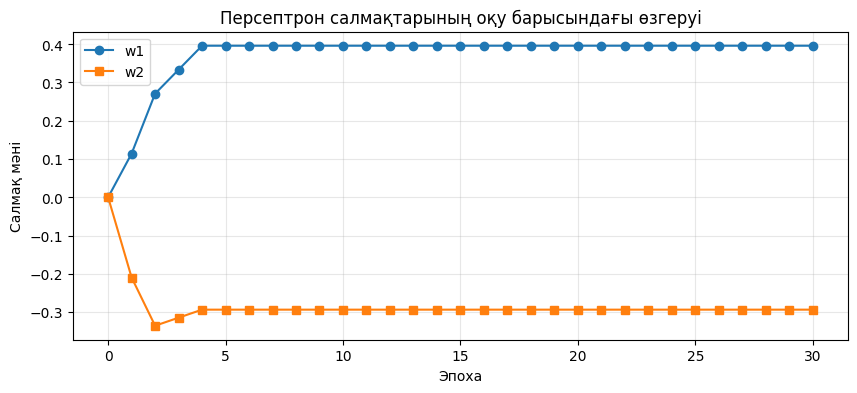

In [11]:
# Тапсырма 2.3
# Персептрон оқу барысындағы салмақтар тарихын жазатын кеңейтілген нұсқа

class PerceptronTracked(Perceptron):
    """Салмақтар тарихын жазатын персептрон."""
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.weight_history = [self.weights.copy()]  # тарих
        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi.reshape(1, -1))[0]
                update = self.lr * (yi - y_pred)
                self.weights += update * xi
                self.bias += update
                if update != 0:
                    errors += 1
            self.weight_history.append(self.weights.copy())
            self.errors_per_epoch.append(errors)
        return self

# 2 белгілі Iris деректерімен (X_scaled, y_iris жоғарыда анықталған)
ppn_tr = PerceptronTracked(learning_rate=0.1, n_epochs=30)
ppn_tr.fit(X_scaled, y_iris)
w_hist = np.array(ppn_tr.weight_history)  # (n_epochs+1, 2)

# TODO: plt.plot арқылы w1 және w2 өзгеруін эпохалар бойынша салыңыз
# Кеңес: w_hist[:, 0] — w1 тарихы, w_hist[:, 1] — w2 тарихы
plt.figure(figsize=(10, 4))
plt.plot(
    range(len(w_hist)),
    w_hist[:, 0],
    marker='o',
    label='w1'
)
plt.plot(
    range(len(w_hist)),
    w_hist[:, 1],
    marker='s',
    label='w2'
)

plt.xlabel("Эпоха")
plt.ylabel("Салмақ мәні")
plt.title("Персептрон салмақтарының оқу барысындағы өзгеруі")
plt.legend()
plt.show()




## Жағдайлық зерттеу 1 (Case Study 1) — AND және OR логикалық қақпаларын жіктеу

**Мақсат:** Персептронмен AND және OR логикалық функцияларын оқытып, оның сызықты ажыратылатын деректерге ғана жарамдылығын тексеру.

**Деректер:** Қолмен жасалған логикалық кесте (4 нүкте, 2 белгі).

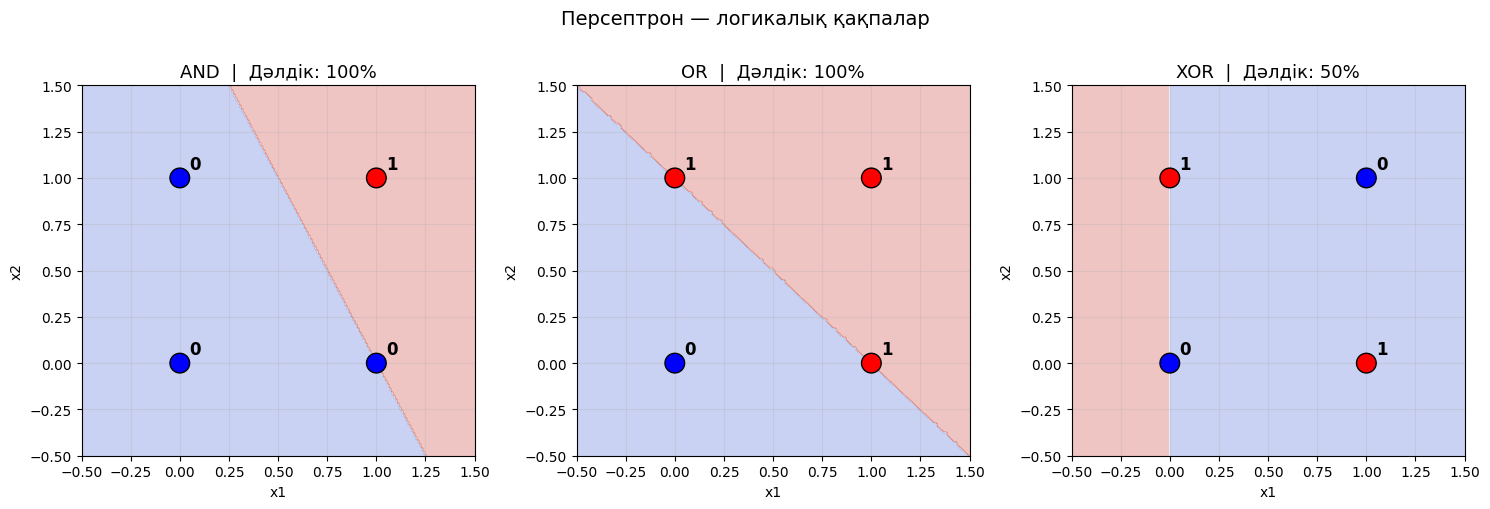

Нәтижелер:
  AND: Дәлдік = 100%  -> ЖАРАЙДЫ
  OR: Дәлдік = 100%  -> ЖАРАЙДЫ
  XOR: Дәлдік = 50%  -> ШЕШЕ АЛМАЙДЫ


In [12]:
# AND деректері
X_logic = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]], dtype=float)

y_and = np.array([0, 0, 0, 1])  # AND
y_or  = np.array([0, 1, 1, 1])  # OR
y_xor = np.array([0, 1, 1, 0])  # XOR — персептрон шеше алмайды!

results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['AND', 'OR', 'XOR']
targets = [y_and, y_or, y_xor]

for ax, title, y in zip(axes, titles, targets):
    model = Perceptron(learning_rate=0.1, n_epochs=200)
    model.fit(X_logic, y)
    y_pred = model.predict(X_logic)
    acc = accuracy_score(y, y_pred)
    results[title] = acc

    # Визуализация
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    colors_pts = ['blue' if yi == 0 else 'red' for yi in y]
    ax.scatter(X_logic[:, 0], X_logic[:, 1], c=colors_pts, s=200,
               edgecolors='black', zorder=5)
    for i, (xi, yi) in enumerate(zip(X_logic, y)):
        ax.text(xi[0] + 0.05, xi[1] + 0.05, str(int(yi)), fontsize=12, fontweight='bold')
    ax.set_title(f"{title}  |  Дәлдік: {acc*100:.0f}%", fontsize=13)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)

plt.suptitle("Персептрон — логикалық қақпалар", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Нәтижелер:")
for name, acc in results.items():
    status = "ЖАРАЙДЫ" if acc == 1.0 else "ШЕШЕ АЛМАЙДЫ"
    print(f"  {name}: Дәлдік = {acc*100:.0f}%  -> {status}")

In [14]:
# Case Study 1 — Студент тапсырмасы
# TODO: NAND (NOT-AND) логикалық функциясын жазыңыз және персептронды оқытыңыз.
# NAND кестесі: (0,0)->1, (0,1)->1, (1,0)->1, (1,1)->0

# NAND кестесі
y_nand = np.array([1, 1, 1, 0])

# Персептрон жасау
model_nand = Perceptron(learning_rate=0.1, n_epochs=200)

# Оқыту
model_nand.fit(X_logic, y_nand)

# Болжау
y_pred_nand = model_nand.predict(X_logic)

# Дәлдік
acc_nand = accuracy_score(y_nand, y_pred_nand)

# Нәтиже
print(f"NAND дәлдігі: {acc_nand * 100:.0f}%")
print("Болжаулар:", y_pred_nand)

NAND дәлдігі: 100%
Болжаулар: [1 1 1 0]


### Тапсырма CS1-Б — OR функциясын персептронсыз «қолмен» оқыту

**Мақсат:** Оқу ережесін (Perceptron Learning Rule) қолмен қадам-қадам қолданып, OR функциясы үшін дұрыс салмақтарды іздеу.

In [15]:
# Тапсырма CS1-Б
# OR кестесі: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->1
X_or = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_or_b = np.array([0, 1, 1, 1], dtype=float)

# Бастапқы салмақтар
w_manual = np.array([0.0, 0.0])
b_manual = 0.0
lr_manual = 0.1

# TODO: 3 эпоха бойынша оқу ережесін қолмен іске асырыңыз:
#   for each (xi, yi) in zip(X_or, y_or_b):
#       y_pred = 1 if np.dot(w_manual, xi) + b_manual >= 0 else 0
#       update = lr_manual * (yi - y_pred)
#       w_manual += update * xi
#       b_manual += update
# Кеңес: w_manual мен b_manual мәндерін print арқылы бақылаңыз

for epoch in range(3):
    print(f"\n--- Эпоха {epoch+1} ---")
    for xi, yi in zip(X_or, y_or_b):
        # TODO: y_pred есептеңіз
        y_pred_m = 1 if np.dot(w_manual, xi) + b_manual >= 0 else 0
        # TODO: update есептеңіз
        update_m = lr_manual * (yi - y_pred_m)
        # TODO: w_manual және b_manual жаңартыңыз
        w_manual += update_m * xi
        b_manual += update_m

        print(
            f"  x={xi}, y={yi}, pred={y_pred_m}, "
            f"update={update_m:.1f}, w={w_manual}, b={b_manual:.1f}"
        )

print(f"\nАқырғы салмақтар: w={w_manual}, b={b_manual:.2f}")



--- Эпоха 1 ---
  x=[0. 0.], y=0.0, pred=1, update=-0.1, w=[0. 0.], b=-0.1
  x=[0. 1.], y=1.0, pred=0, update=0.1, w=[0.  0.1], b=0.0
  x=[1. 0.], y=1.0, pred=1, update=0.0, w=[0.  0.1], b=0.0
  x=[1. 1.], y=1.0, pred=1, update=0.0, w=[0.  0.1], b=0.0

--- Эпоха 2 ---
  x=[0. 0.], y=0.0, pred=1, update=-0.1, w=[0.  0.1], b=-0.1
  x=[0. 1.], y=1.0, pred=1, update=0.0, w=[0.  0.1], b=-0.1
  x=[1. 0.], y=1.0, pred=0, update=0.1, w=[0.1 0.1], b=0.0
  x=[1. 1.], y=1.0, pred=1, update=0.0, w=[0.1 0.1], b=0.0

--- Эпоха 3 ---
  x=[0. 0.], y=0.0, pred=1, update=-0.1, w=[0.1 0.1], b=-0.1
  x=[0. 1.], y=1.0, pred=1, update=0.0, w=[0.1 0.1], b=-0.1
  x=[1. 0.], y=1.0, pred=1, update=0.0, w=[0.1 0.1], b=-0.1
  x=[1. 1.], y=1.0, pred=1, update=0.0, w=[0.1 0.1], b=-0.1

Ақырғы салмақтар: w=[0.1 0.1], b=-0.10




# 3-бөлім. Активация функциялары

**Мақсат:** Жиі қолданылатын активация функцияларының математикалық формулаларын, графиктерін және олардың туындыларын (derivative) меңгеру.

---

## Теориялық негіз

Активация функциясы нейронның шығысына сызықты еместік (non-linearity) қасиетін береді. Сызықты еместіксіз желі тек сызықты функцияларды модельдей алар еді.

**Негізгі активация функциялары:**

| Атауы | Формула | Диапазон | Қолдану аймағы |
|-------|---------|----------|----------------|
| Sigmoid | 1 / (1 + e^(-z)) | (0, 1) | Бинарлық жіктеу (шығыс қабаты) |
| Tanh | (e^z - e^(-z)) / (e^z + e^(-z)) | (-1, 1) | Жасырын қабаттар |
| ReLU | max(0, z) | [0, +inf) | Терең желілер (ең кең тараған) |
| Leaky ReLU | max(0.01z, z) | (-inf, +inf) | ReLU-дің жетілдірілгені |
| Softmax | e^zi / sum(e^z) | (0, 1), sum=1 | Көп кластық жіктеу (шығыс) |

**Туынды маңыздылығы:** Кері таралу алгоритмі (backpropagation) активация функциясының туындысын қолданады. Туынды нольге жақын болса, «жоғалатын градиент» (vanishing gradient) проблемасы туындайды.

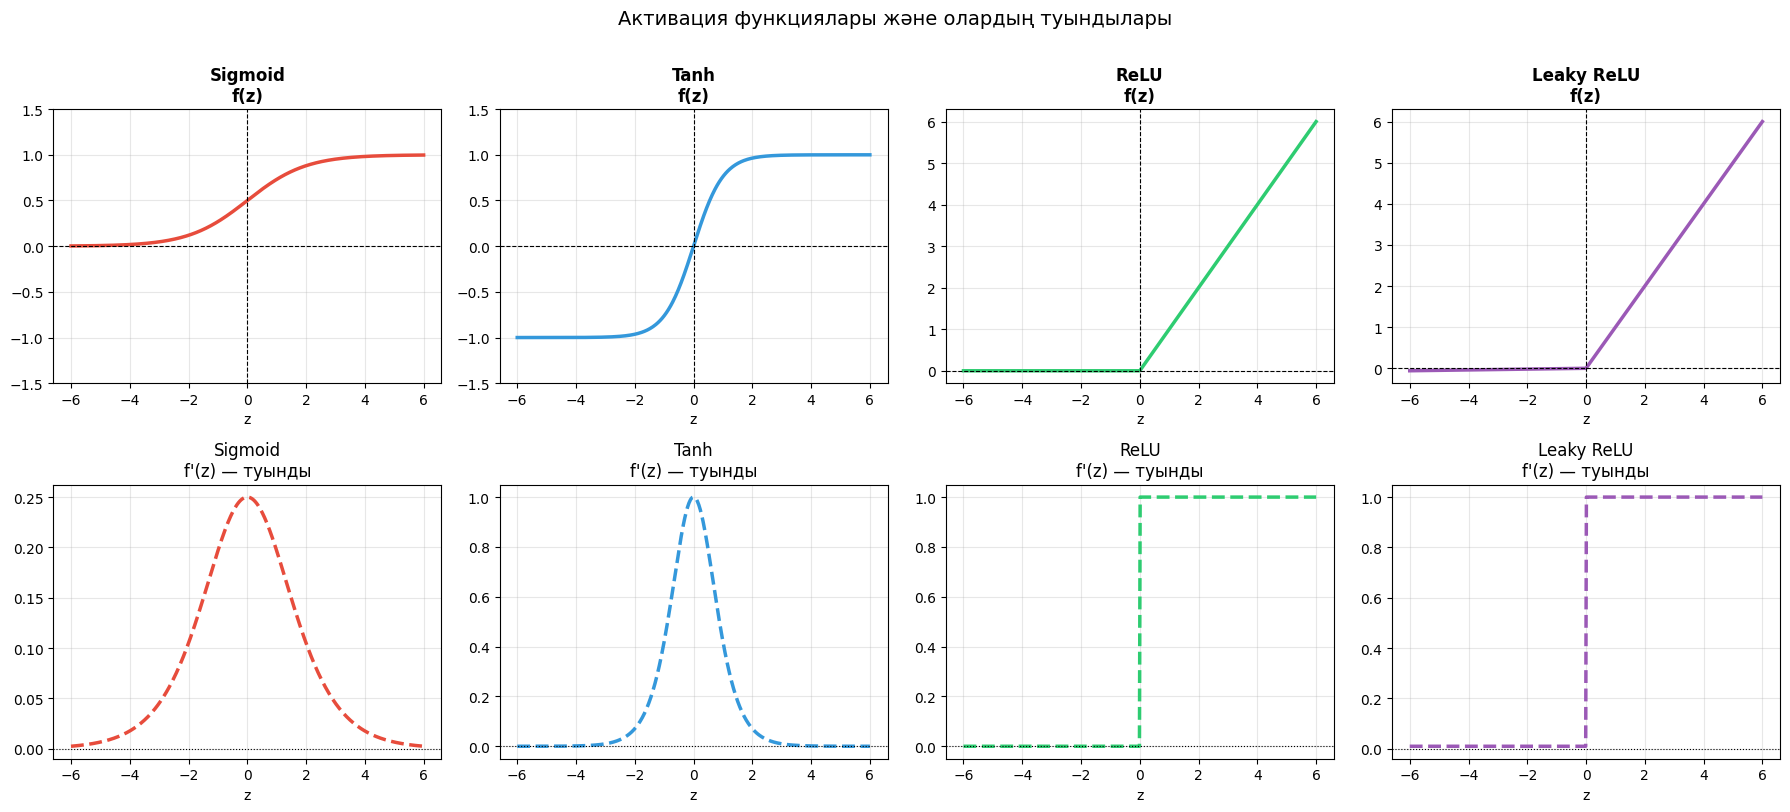

z = 0.5 нүктесіндегі мәндер:
  Sigmoid:     f(0.5) = 0.6225,  f'(0.5) = 0.2350
  Tanh:        f(0.5) = 0.4621,  f'(0.5) = 0.7864
  ReLU:        f(0.5) = 0.5000,  f'(0.5) = 1.0000
  Leaky ReLU:  f(0.5) = 0.5000,  f'(0.5) = 1.0000


In [16]:
# Активация функциялары және олардың туындылары

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1.0, 0.0)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)


z = np.linspace(-6, 6, 500)

funcs = [
    ('Sigmoid', sigmoid(z), sigmoid_derivative(z), '#e74c3c'),
    ('Tanh', tanh(z), tanh_derivative(z), '#3498db'),
    ('ReLU', relu(z), relu_derivative(z), '#2ecc71'),
    ('Leaky ReLU', leaky_relu(z), leaky_relu_derivative(z), '#9b59b6'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, (name, f_vals, df_vals, color) in enumerate(funcs):
    # Функция
    axes[0, i].plot(z, f_vals, color=color, linewidth=2.5)
    axes[0, i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0, i].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0, i].set_title(f"{name}\nf(z)", fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel("z")
    axes[0, i].set_ylim(-1.5, 1.5) if name in ['Sigmoid', 'Tanh'] else None

    # Туынды
    axes[1, i].plot(z, df_vals, color=color, linewidth=2.5, linestyle='--')
    axes[1, i].axhline(0, color='black', linewidth=0.8, linestyle=':')
    axes[1, i].set_title(f"{name}\nf'(z) — туынды", fontsize=12)
    axes[1, i].set_xlabel("z")

plt.suptitle("Активация функциялары және олардың туындылары", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Белгілі нүктедегі мәндер
z_test = 0.5
print(f"z = {z_test} нүктесіндегі мәндер:")
print(f"  Sigmoid:     f({z_test}) = {sigmoid(z_test):.4f},  f'({z_test}) = {sigmoid_derivative(z_test):.4f}")
print(f"  Tanh:        f({z_test}) = {tanh(z_test):.4f},  f'({z_test}) = {tanh_derivative(z_test):.4f}")
print(f"  ReLU:        f({z_test}) = {relu(z_test):.4f},  f'({z_test}) = {relu_derivative(z_test):.4f}")
print(f"  Leaky ReLU:  f({z_test}) = {leaky_relu(z_test):.4f},  f'({z_test}) = {leaky_relu_derivative(z_test):.4f}")

### Тапсырма 3.1 — Softmax функциясын іске асыру

**Мақсат:** Softmax функциясын нуль деңгейден жазып, оның қасиеттерін (барлық мәндердің қосындысы = 1) тексеру.

Формула: softmax(z_i) = exp(z_i) / sum(exp(z_j))

Кіріс (логиттер):       [ 2.   1.   0.5 -1. ]
Softmax шығысы:         [0.60946004 0.22420782 0.13598892 0.03034323]
Барлық мәндердің қосындысы: 1.000000  (1.0 болуы тиіс)


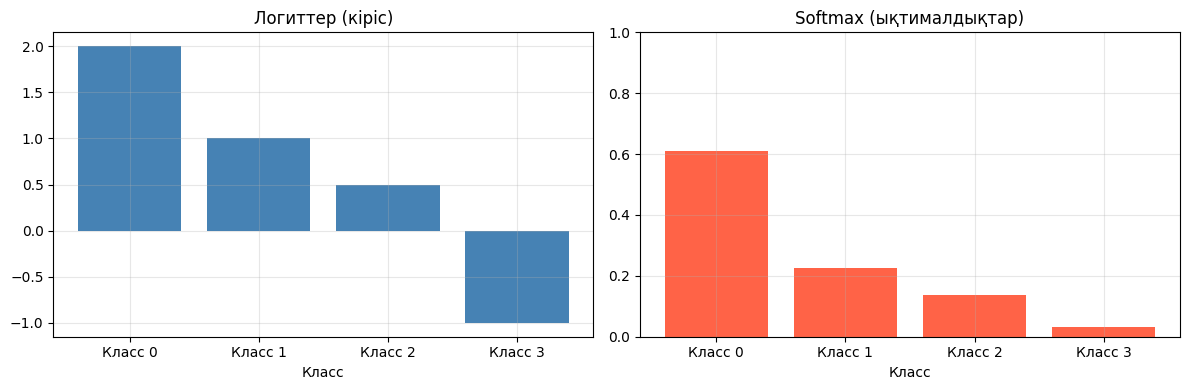

In [17]:
# Тапсырма 3.1

def softmax(z):
    """
    Softmax функциясы.
    Кіріс: z — 1D numpy массив (логиттер)
    Шығыс: ықтималдықтар векторы
    """
    # Кеңес: Сандық тұрақтылық үшін z-дан max(z) азайтыңыз:
    # exp_z = np.exp(z - np.max(z))
    # Сонда exp_z / exp_z.sum() қайтарыңыз

    # TODO: softmax іске асырыңыз
    exp_z = np.exp(z - np.max(z))

    return exp_z / exp_z.sum()


# Тест векторы
z_test = np.array([2.0, 1.0, 0.5, -1.0])
result = softmax(z_test)

print(f"Кіріс (логиттер):       {z_test}")
print(f"Softmax шығысы:         {result}")
print(f"Барлық мәндердің қосындысы: {result.sum():.6f}  (1.0 болуы тиіс)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [f'Класс {i}' for i in range(len(z_test))]
axes[0].bar(labels, z_test, color='steelblue')
axes[0].set_title("Логиттер (кіріс)")
axes[1].bar(labels, result, color='tomato')
axes[1].set_title("Softmax (ықтималдықтар)")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.set_xlabel("Класс")
plt.tight_layout()
plt.show()

### Тапсырма 3.2 — ReLU туындысын визуализациялау

**Мақсат:** ReLU функциясы мен оның туындысының «өлі нейрон» (dying neuron) проблемасымен байланысын графикте анықтау.

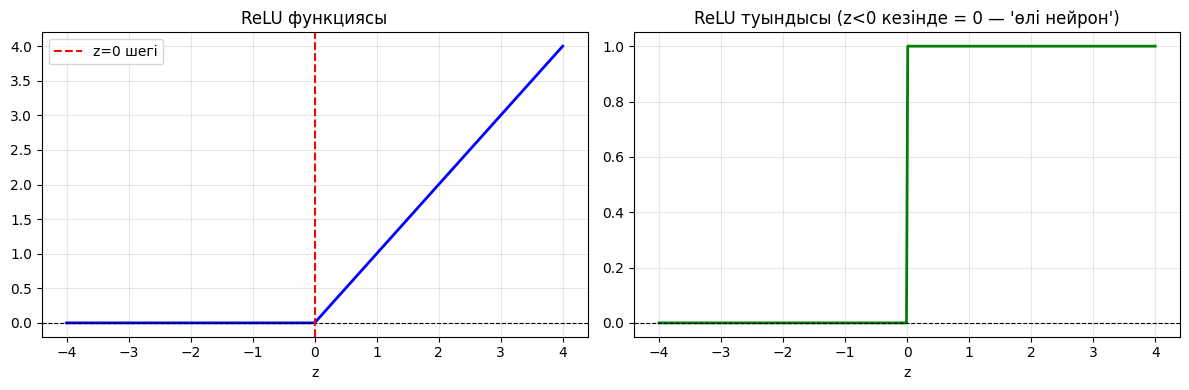

z < 0 аймағында туынды = 0. Мұны 'dying ReLU' деп атайды.


In [18]:
# Тапсырма 3.2
z_range = np.linspace(-4, 4, 400)

# TODO: relu_vals және relu_deriv_vals есептеңіз
relu_vals = relu(z_range)
relu_deriv_vals = relu_derivative(z_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO: axes[0]-ге ReLU функциясын салыңыз
# axes[0].plot(...)
axes[0].plot(z_range, relu_vals, color='blue', linewidth=2)
axes[0].set_title("ReLU функциясы")
axes[0].set_xlabel("z")
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].axvline(0, color='red', lw=1.5, ls='--', label='z=0 шегі')
axes[0].legend()

# TODO: axes[1]-ге ReLU туындысын салыңыз
axes[1].plot(z_range, relu_deriv_vals, color='green', linewidth=2)
axes[1].set_title("ReLU туындысы (z<0 кезінде = 0 — 'өлі нейрон')")
axes[1].set_xlabel("z")
axes[1].axhline(0, color='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

print("z < 0 аймағында туынды = 0. Мұны 'dying ReLU' деп атайды.")


### Тапсырма 3.3 — Активация функцияларын сандық тұрақтылыққа тексеру

**Мақсат:** Өте үлкен z мәндерінде (z=1000) sigmoid, tanh, relu функцияларының қандай мән беретінін тексеріп, nan/overflow мәселесін аулау.

In [19]:
# Тапсырма 3.3
# Кеңес: np.exp(1000) -> overflow, np.exp(-1000) -> 0
# Sigmoid үшін: np.clip(z, -500, 500) қолданылады

z_extreme = np.array([-1000.0, -10.0, 0.0, 10.0, 1000.0])

# TODO: Клипсіз (raw) sigmoid есептеп, overflow-ды байқаңыз
# raw_sigmoid = 1 / (1 + np.exp(-z_extreme))  — бұл ескерту береді
raw_sigmoid = 1 / (1 + np.exp(-z_extreme))

print("Raw sigmoid:")
print(raw_sigmoid)

# TODO: Клиппен (safe) sigmoid есептеңіз
def safe_sigmoid(z):
    # TODO: np.clip қолданып іске асырыңыз
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))

safe_out = safe_sigmoid(z_extreme)

print("z мәндері:      ", z_extreme)
print("safe sigmoid:   ", safe_out)
print("tanh:           ", np.tanh(z_extreme))
print("relu:           ", np.maximum(0, z_extreme))
print("\nReLU өте үлкен мәндерде де жұмыс істейді (exploding activation мәселесіне назар аударыңыз).")


Raw sigmoid:
[0.00000000e+00 4.53978687e-05 5.00000000e-01 9.99954602e-01
 1.00000000e+00]
z мәндері:       [-1000.   -10.     0.    10.  1000.]
safe sigmoid:    [7.12457641e-218 4.53978687e-005 5.00000000e-001 9.99954602e-001
 1.00000000e+000]
tanh:            [-1. -1.  0.  1.  1.]
relu:            [   0.    0.    0.   10. 1000.]

ReLU өте үлкен мәндерде де жұмыс істейді (exploding activation мәселесіне назар аударыңыз).




# 4-бөлім. Көпқабатты желі (MLP)

**Мақсат:** Көпқабатты перцептронның архитектурасын, қабат түрлерін және параметр санын есептеуді практика арқылы меңгеру.

---

## Теориялық негіз

Көпқабатты перцептрон (Multilayer Perceptron, MLP) — бірнеше қабаттан тұратын жасанды нейрондық желі:

1. **Кіріс қабаты (Input layer):** Деректердің белгілерін (features) қабылдайды. Нейрон саны = белгілер саны.
2. **Жасырын қабаттар (Hidden layers):** Бір немесе бірнеше болуы мүмкін. Деректерден күрделі үлгілерді (patterns) меңгереді.
3. **Шығыс қабаты (Output layer):** Соңғы болжамды шығарады. Нейрон саны = класс саны (жіктеу үшін).

**Параметр саны формуласы:**

L-1 және L қабаттары арасындағы параметр саны:

```
Параметрлер = (n_{L-1} + 1) * n_L
```

мұнда `+1` — bias нейроны үшін.

**Терең желілер:** Жасырын қабат саны артқан сайын желі күрделірек функцияларды меңгере алады, бірақ артық оқу (overfitting) қаупі де артады.

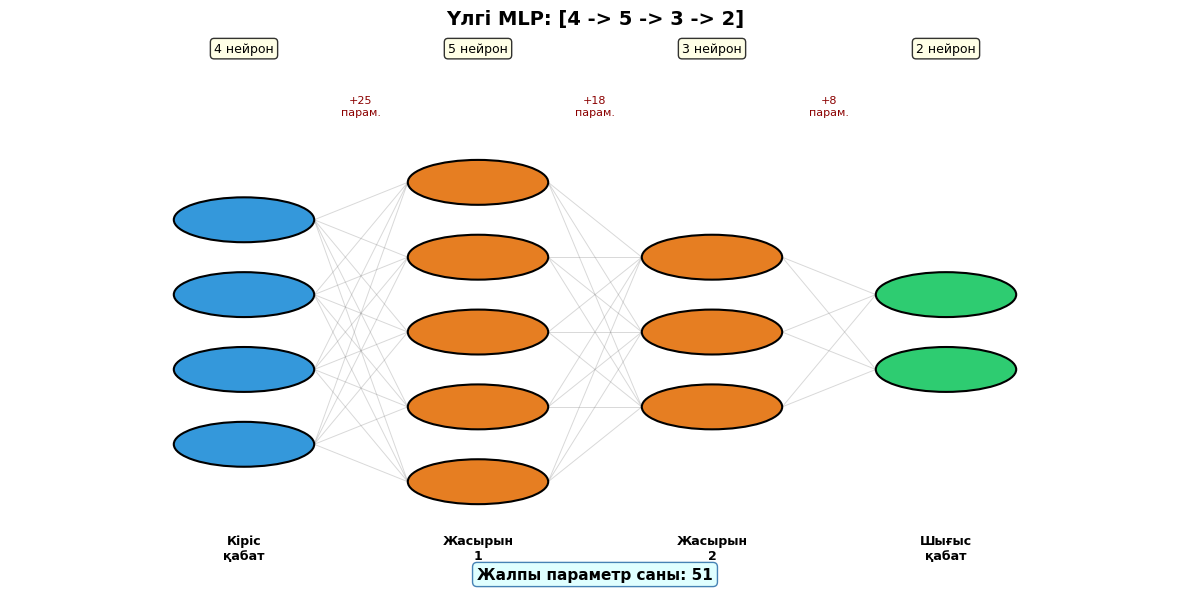

Жалпы параметр саны: 51


In [20]:
# MLP архитектурасын визуализациялайтын функция

def visualize_mlp(layer_sizes, title="MLP архитектурасы"):
    """
    layer_sizes: список нейрон санының — [кіріс, жасырын1, ..., шығыс]
    """
    n_layers = len(layer_sizes)
    max_neurons = max(layer_sizes)

    fig, ax = plt.subplots(figsize=(3 * n_layers, max(5, max_neurons + 1)))
    ax.set_xlim(0, n_layers + 1)
    ax.set_ylim(0, max_neurons + 2)
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

    layer_colors = ['#3498db', '#e67e22', '#2ecc71']
    layer_names = ['Кіріс\nқабат'] + [f'Жасырын\n{i+1}' for i in range(n_layers - 2)] + ['Шығыс\nқабат']

    neuron_positions = []
    total_params = 0

    for l, n in enumerate(layer_sizes):
        x = l + 1
        color = layer_colors[0] if l == 0 else (layer_colors[2] if l == n_layers - 1 else layer_colors[1])
        y_positions = []
        y_start = (max_neurons - n) / 2 + 1

        for ni in range(n):
            y = y_start + ni
            y_positions.append(y)
            circle = plt.Circle((x, y), 0.3, color=color, ec='black', linewidth=1.5, zorder=3)
            ax.add_patch(circle)

        neuron_positions.append(y_positions)
        ax.text(x, 0.3, layer_names[l], ha='center', va='top', fontsize=9, fontweight='bold')
        ax.text(x, max_neurons + 1.7, f'{n} нейрон', ha='center', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Байланыстарды сызамыз
    for l in range(n_layers - 1):
        for y1 in neuron_positions[l]:
            for y2 in neuron_positions[l + 1]:
                ax.plot([l + 1.3, l + 1.7], [y1, y2], color='gray', alpha=0.3, linewidth=0.7)
        params = (layer_sizes[l] + 1) * layer_sizes[l + 1]
        total_params += params
        mid_x = l + 1.5
        ax.text(mid_x, max_neurons + 0.9, f'+{params}\nпарам.', ha='center', fontsize=8, color='darkred')

    ax.text(n_layers / 2 + 0.5, -0.3,
            f"Жалпы параметр саны: {total_params:,}",
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightcyan', edgecolor='steelblue'))

    plt.tight_layout()
    plt.show()
    return total_params


# Мысал: 4 -> 5 -> 3 -> 2
params = visualize_mlp([4, 5, 3, 2], title="Үлгі MLP: [4 -> 5 -> 3 -> 2]")
print(f"Жалпы параметр саны: {params}")

### Тапсырма 4.1 — Параметр санын есептеу

**Мақсат:** MLP архитектурасын жобалап, параметр санын қолмен есептеп, визуализациямен тексеру.

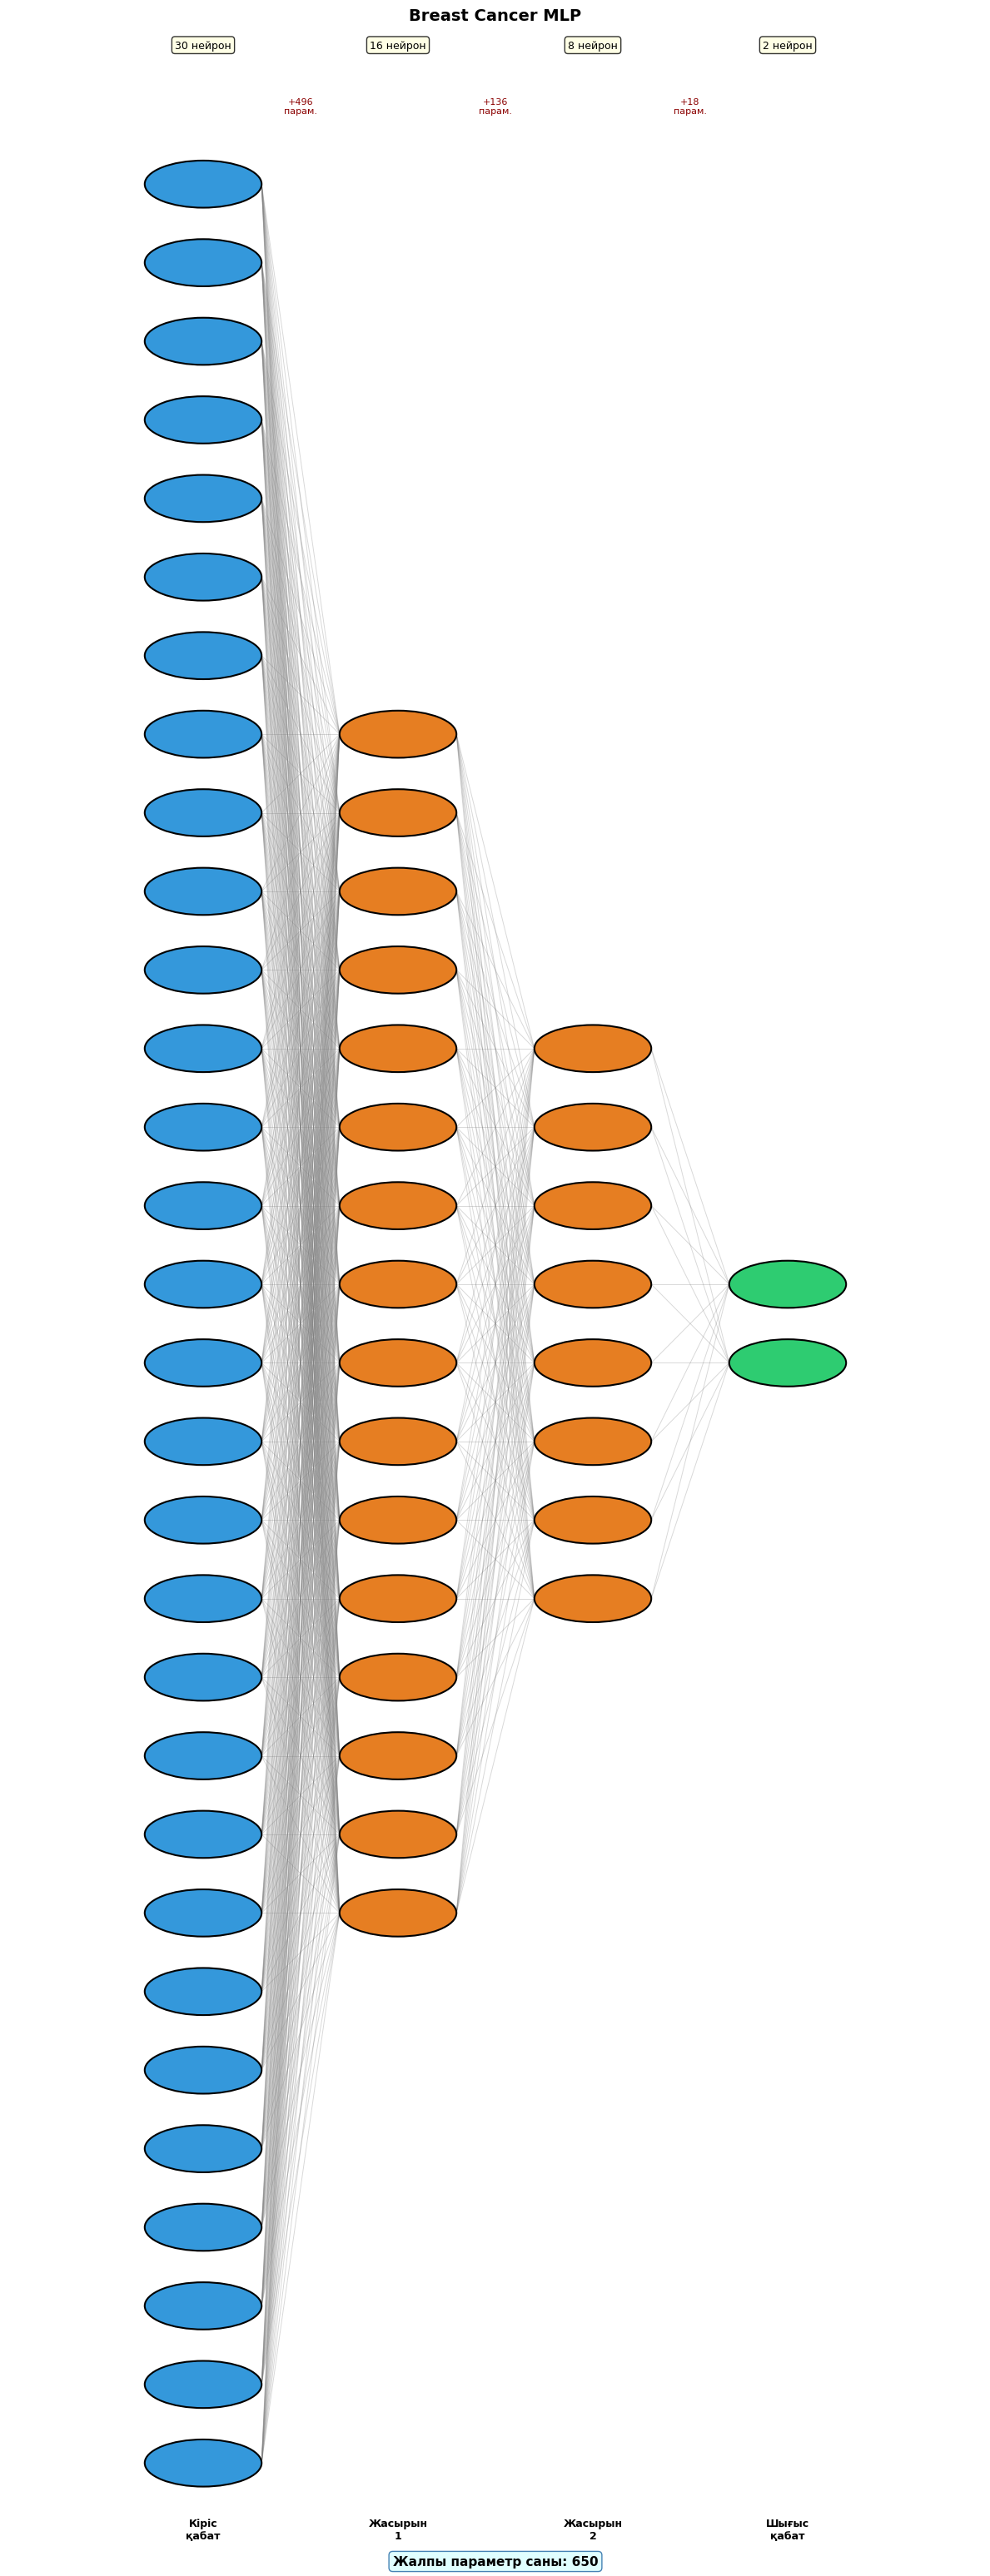

1-қабат: 496
2-қабат: 136
3-қабат: 18

Қолмен есептелген параметр саны: 650
Визуализациядан алынған сан: 650
Сандар сәйкес келді: True


In [21]:
# Тапсырма 4.1
# Breast Cancer деректер жиыны үшін:
# - Кіріс: 30 белгі
# - Жасырын қабат 1: 16 нейрон
# - Жасырын қабат 2: 8 нейрон
# - Шығыс: 2 класс (қатерлі / қатерлі емес)

# TODO: layer_sizes тізімін анықтаңыз
layer_sizes = [30, 16, 8, 2]

# TODO: visualize_mlp функциясын шақырыңыз
params = visualize_mlp(layer_sizes, title="Breast Cancer MLP")
# ???

# TODO: Параметр санын қолмен есептеп тексеріңіз
# 1-қабат аралығы: (30 + 1) * 16 = ?
# 2-қабат аралығы: (16 + 1) * 8 = ?
# 3-қабат аралығы: (8 + 1) * 2 = ?
# Жалпы: ? + ? + ? = ?
layer1 = (30 + 1) * 16
layer2 = (16 + 1) * 8
layer3 = (8 + 1) * 2
manual_count = layer1 + layer2 + layer3
print(f"1-қабат: {layer1}")
print(f"2-қабат: {layer2}")
print(f"3-қабат: {layer3}")

print(f"\nҚолмен есептелген параметр саны: {manual_count}")
print(f"Визуализациядан алынған сан: {params}")
print(f"Сандар сәйкес келді: {manual_count == params}")

### Тапсырма 4.2 — Желі архитектурасын жобалау

**Мақсат:** Wine деректері үшін параметр санын 500-ден аспайтын MLP архитектурасын таңдап, визуализациялау.

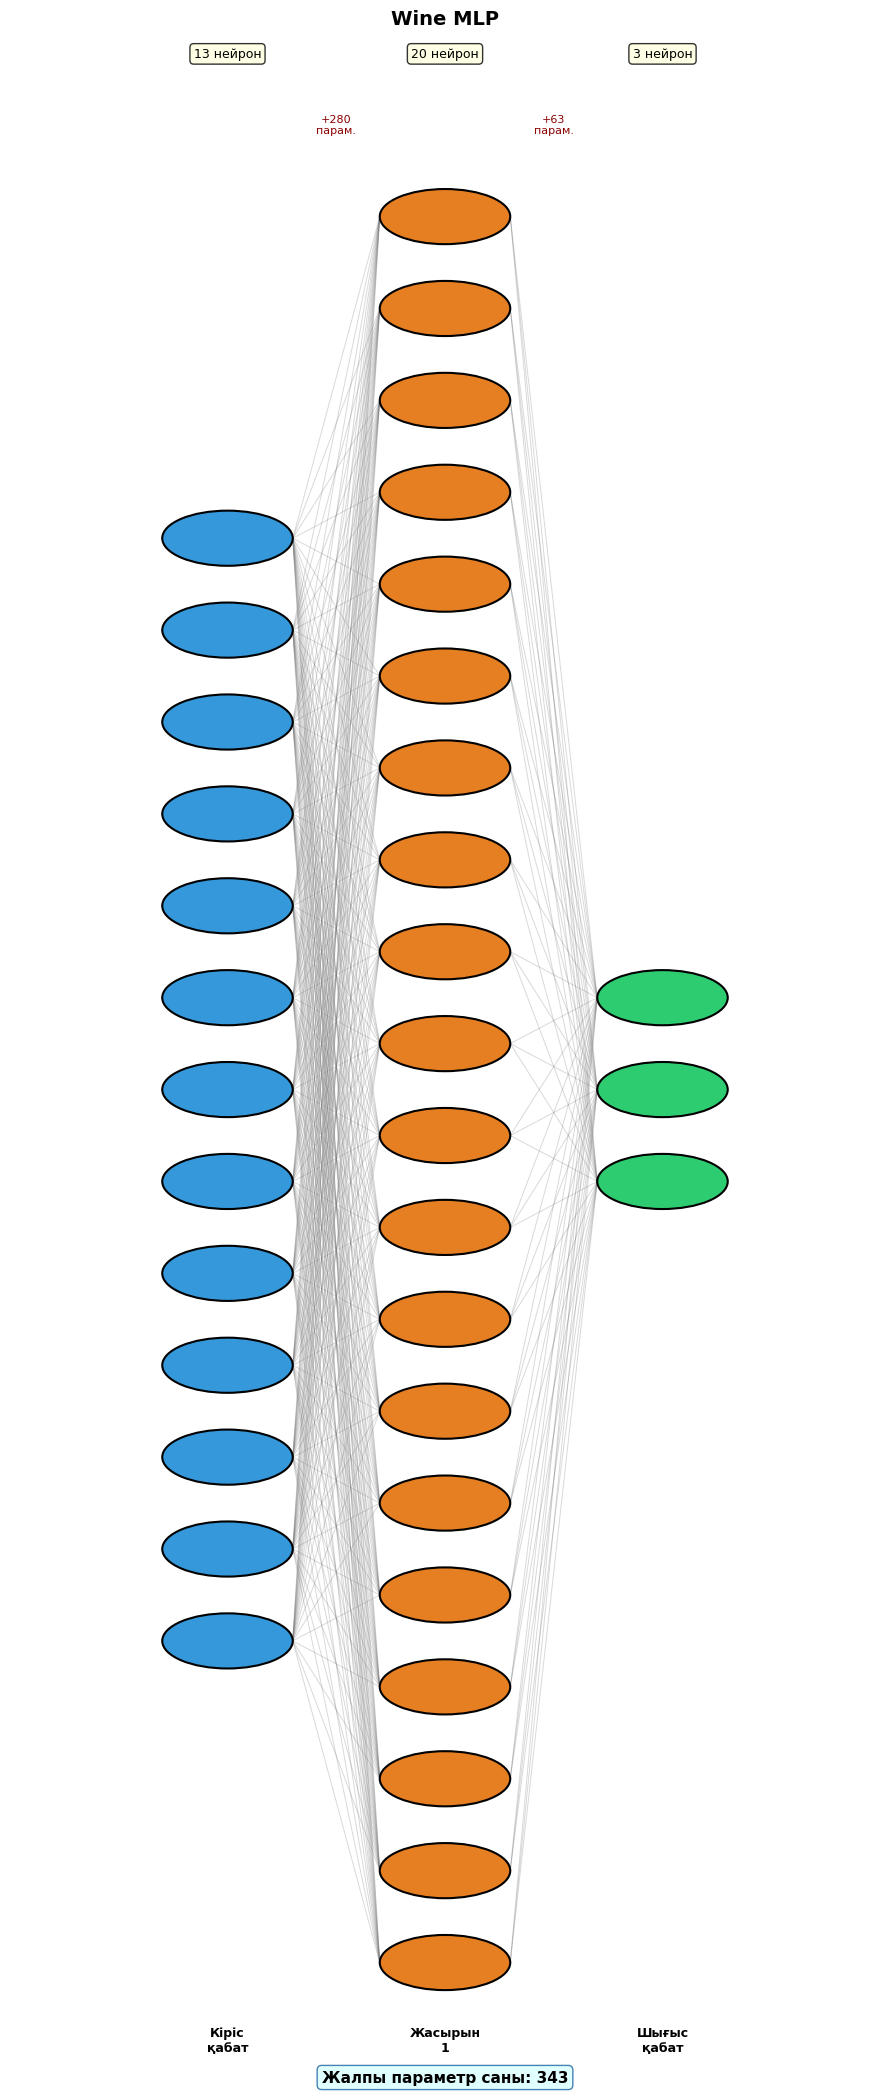

Жалпы параметр саны: 343
Параметр саны 500-ден аспайды: True


In [22]:
# Тапсырма 4.2
# Wine деректері: 13 кіріс белгі, 3 класс (шығыс)
# Параметр саны 500-ден аспасын деген шарт бар.
# Кеңес: (13+1)*n1 + (n1+1)*3 <= 500 теңсіздігін шешіңіз

# TODO: Дұрыс n_hidden мәнін тауып, layer_sizes_wine анықтаңыз
# Мысалы: [13, n_hidden, 3]
layer_sizes_wine = [13, 20, 3]

# TODO: visualize_mlp шақырып, параметр санын тексеріңіз
params_wine = visualize_mlp(
    layer_sizes_wine,
    title="Wine MLP"
)

print(f"Жалпы параметр саны: {params_wine}")
# TODO: params_wine <= 500 екенін тексеріңіз
print(f"Параметр саны 500-ден аспайды: {params_wine <= 500}")


### Тапсырма 4.3 — Параметр санын деректер жиыны бойынша кестеде жинақтау

**Мақсат:** Iris, Wine, Breast Cancer үшін бірдей (16, 8) жасырын желінің параметр санын есептеп, кестеге шығару.

In [23]:
# Тапсырма 4.3
# Деректер жиындары: Iris (4 белгі, 3 класс), Wine (13, 3), BC (30, 2)
datasets_info = [
    ('Iris',         4,  3),
    ('Wine',        13,  3),
    ('Breast Cancer', 30, 2),
]

print(f"{'Деректер жиыны':<20} {'Кіріс':>6} {'Шығыс':>7} {'Параметр саны':>15}")
print("-" * 52)

for name_ds, n_in, n_out in datasets_info:
    # TODO: (n_in->16->8->n_out) архитектурасы үшін параметр санын есептеңіз
    # Формула: (n_in+1)*16 + (16+1)*8 + (8+1)*n_out
    total_params_ds = (
        (n_in + 1) * 16 +
        (16 + 1) * 8 +
        (8 + 1) * n_out
    )

    print(f"{name_ds:<20} {n_in:>6} {n_out:>7} {total_params_ds:>15,}")


Деректер жиыны        Кіріс   Шығыс   Параметр саны
----------------------------------------------------
Iris                      4       3             243
Wine                     13       3             387
Breast Cancer            30       2             650




# 5-бөлім. Тура таралу (Forward Propagation)

**Мақсат:** Кіріс деректерден шығыс болжамға дейінгі есептеу процесін қабат-қабат меңгеру.

---

## Теориялық негіз

Тура таралу (forward propagation) — деректердің кіріс қабатынан шығыс қабатқа дейін бірізді өтуі. Әрбір қабатта мына есептеулер жүргізіледі:

```
Z[l] = W[l] * A[l-1] + b[l]       <- сызықты қадам
A[l] = f(Z[l])                     <- активация
```

мұнда:
- `W[l]` — l-ші қабаттың салмақ матрицасы
- `b[l]` — l-ші қабаттың bias векторы
- `f` — активация функциясы
- `A[0] = X` — кіріс деректер

**Жоғалту функциясы (Loss Function):**

Болжам мен шынайы мән арасындағы айырманы өлшейді:

- Binary Cross-Entropy: L = -(y*log(a) + (1-y)*log(1-a))
- Categorical Cross-Entropy: L = -sum(y_i * log(a_i))
- MSE: L = (1/n) * sum((y - a)^2)

In [24]:
# Тура таралуды нуль деңгейден іске асыру

class SimpleMLP:
    """
    Қарапайым 2 жасырын қабатты MLP:
    кіріс -> жасырын1 (ReLU) -> жасырын2 (ReLU) -> шығыс (Sigmoid)
    """

    def __init__(self, n_input, n_hidden1, n_hidden2, n_output, seed=42):
        np.random.seed(seed)
        # Салмақтарды кішігірім кездейсоқ мәндермен инициализациялаймыз (He инициализациясы)
        self.W1 = np.random.randn(n_input, n_hidden1) * np.sqrt(2.0 / n_input)
        self.b1 = np.zeros((1, n_hidden1))
        self.W2 = np.random.randn(n_hidden1, n_hidden2) * np.sqrt(2.0 / n_hidden1)
        self.b2 = np.zeros((1, n_hidden2))
        self.W3 = np.random.randn(n_hidden2, n_output) * np.sqrt(2.0 / n_hidden2)
        self.b3 = np.zeros((1, n_output))

    def _relu(self, z):
        return np.maximum(0, z)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        """Тура таралу."""
        # 1-қабат
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self._relu(self.Z1)

        # 2-қабат
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self._relu(self.Z2)

        # Шығыс қабат
        self.Z3 = self.A2 @ self.W3 + self.b3
        self.A3 = self._sigmoid(self.Z3)

        return self.A3

    def compute_loss(self, y_true, y_pred):
        """Binary Cross-Entropy жоғалту функциясы."""
        eps = 1e-8  # Log(0) мәселесін болдырмаймыз
        loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
        return loss


# Breast Cancer деректер жиынымен тексерейік
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target.reshape(-1, 1)

scaler_c = StandardScaler()
X_cancer_scaled = scaler_c.fit_transform(X_cancer)

# Модель жасаймыз
mlp = SimpleMLP(n_input=30, n_hidden1=16, n_hidden2=8, n_output=1)

# Тура таралуды орындаймыз
y_pred_raw = mlp.forward(X_cancer_scaled)
initial_loss = mlp.compute_loss(y_cancer, y_pred_raw)

print("Тура таралу нәтижесі:")
print(f"  Кіріс пішіні (shape): {X_cancer_scaled.shape}")
print(f"  Z1 пішіні: {mlp.Z1.shape}")
print(f"  A1 пішіні: {mlp.A1.shape}")
print(f"  Z2 пішіні: {mlp.Z2.shape}")
print(f"  A2 пішіні: {mlp.A2.shape}")
print(f"  Шығыс A3 пішіні: {mlp.A3.shape}")
print(f"  Бастапқы жоғалту (loss): {initial_loss:.4f}")
print(f"  Алғашқы 5 болжам ықтималдығы: {y_pred_raw[:5, 0]}")

Тура таралу нәтижесі:
  Кіріс пішіні (shape): (569, 30)
  Z1 пішіні: (569, 16)
  A1 пішіні: (569, 16)
  Z2 пішіні: (569, 8)
  A2 пішіні: (569, 8)
  Шығыс A3 пішіні: (569, 1)
  Бастапқы жоғалту (loss): 0.6974
  Алғашқы 5 болжам ықтималдығы: [0.91474395 0.5267524  0.55500126 0.79140795 0.74920131]




## Жағдайлық зерттеу 2 (Case Study 2) — Тура таралуды қолмен іздеу

**Мақсат:** Шағын желі үшін тура таралу есебін толықтай қолмен орындап, нәтижелерді тексеру.

**Деректер:** Ойдан шығарылған шағын желі (2 -> 3 -> 1).

In [25]:
# Case Study 2: Шағын желіде тура таралу
# Архитектура: 2 кіріс -> 3 жасырын (sigmoid) -> 1 шығыс (sigmoid)

np.random.seed(0)

# Берілген параметрлер
W1_cs = np.array([[0.1, 0.2, -0.3],
                   [0.4, -0.1, 0.5]])
b1_cs = np.array([0.0, 0.0, 0.0])

W2_cs = np.array([[0.3],
                   [-0.2],
                   [0.6]])
b2_cs = np.array([0.0])

# Кіріс мысалы
x_cs = np.array([1.0, 2.0])
y_cs = np.array([1.0])  # Шынайы мән

def sigmoid_cs(z):
    return 1 / (1 + np.exp(-z))

# Тура таралуды қадам-қадаммен орындаймыз
print("=" * 55)
print("ТУРА ТАРАЛУ — ҚАДАМ БОЙЫНША ЕСЕПТЕУ")
print("=" * 55)

# 1-қабат
Z1_cs = x_cs @ W1_cs + b1_cs
A1_cs = sigmoid_cs(Z1_cs)
print(f"\nКіріс x: {x_cs}")
print(f"Z1 = x @ W1 + b1 = {Z1_cs}")
print(f"A1 = sigmoid(Z1) = {A1_cs}")

# 2-қабат (шығыс)
Z2_cs = A1_cs @ W2_cs + b2_cs
A2_cs = sigmoid_cs(Z2_cs)
print(f"\nZ2 = A1 @ W2 + b2 = {Z2_cs}")
print(f"A2 = sigmoid(Z2) = {A2_cs}  <- болжам")

# Жоғалту
eps = 1e-8
loss_cs = -(y_cs * np.log(A2_cs + eps) + (1 - y_cs) * np.log(1 - A2_cs + eps))
print(f"\nШынайы мән y: {y_cs}")
print(f"Binary Cross-Entropy жоғалту: {loss_cs[0]:.6f}")
print("=" * 55)

ТУРА ТАРАЛУ — ҚАДАМ БОЙЫНША ЕСЕПТЕУ

Кіріс x: [1. 2.]
Z1 = x @ W1 + b1 = [0.9 0.  0.7]
A1 = sigmoid(Z1) = [0.7109495  0.5        0.66818777]

Z2 = A1 @ W2 + b2 = [0.51419751]
A2 = sigmoid(Z2) = [0.62578995]  <- болжам

Шынайы мән y: [1.]
Binary Cross-Entropy жоғалту: 0.468740


In [26]:
# Case Study 2 — Студент тапсырмасы
# TODO: Жаңа кіріс үшін тура таралуды есептеңіз
# Жаңа кіріс: x_new = [0.5, -1.0], y_new = 0.0

x_new = np.array([0.5, -1.0])
y_new = np.array([0.0])

# Кеңес: жоғарыдағы W1_cs, b1_cs, W2_cs, b2_cs параметрлерін қолданыңыз
# Қадамдар: Z1_new -> A1_new -> Z2_new -> A2_new -> loss_new

# TODO: Z1_new есептеңіз
Z1_new = x_new @ W1_cs + b1_cs

# TODO: A1_new есептеңіз (sigmoid)
A1_new = sigmoid_cs(Z1_new)

# TODO: Z2_new есептеңіз
Z2_new = A1_new @ W2_cs + b2_cs

# TODO: A2_new есептеңіз (sigmoid) — бұл болжамыңыз
A2_new = sigmoid_cs(Z2_new)

# TODO: Жоғалтуды есептеңіз
loss_new = -(y_new * np.log(A2_new + eps) + (1 - y_new) * np.log(1 - A2_new + eps))

# TODO: Нәтижелерді басып шығарыңыз
print(f"Z1_new: {Z1_new}")
print(f"A1_new: {A1_new}")
print(f"Z2_new: {Z2_new}")
print(f"A2_new (болжам): {A2_new}")
print(f"Loss: {loss_new[0]:.6f}")

Z1_new: [-0.35  0.2  -0.65]
A1_new: [0.41338242 0.549834   0.34298954]
Z2_new: [0.21984165]
A2_new (болжам): [0.55474012]
Loss: 0.809097


### Тапсырма CS2-Б — Бірнеше үлгіде тура таралу (батч)

**Мақсат:** Бір үлгі емес, бірнеше үлгіден тұратын матрицамен тура таралу орындау (батч өңдеу).

In [27]:
# Тапсырма CS2-Б
# Case Study 2 желісін (W1_cs, b1_cs, W2_cs, b2_cs) қолданамыз
# Бірақ бұл жолы 4 үлгіні бір уақытта өңдейміз

X_batch = np.array([
    [1.0,  2.0],
    [0.5, -1.0],
    [-1.0, 0.3],
    [2.0,  1.5],
])
y_batch = np.array([[1.0], [0.0], [0.0], [1.0]])

# TODO: Z1_b = X_batch @ W1_cs + b1_cs есептеңіз
Z1_b = X_batch @ W1_cs + b1_cs

# TODO: A1_b = sigmoid_cs(Z1_b) есептеңіз
A1_b = sigmoid_cs(Z1_b)

# TODO: Z2_b = A1_b @ W2_cs + b2_cs есептеңіз
Z2_b = A1_b @ W2_cs + b2_cs

# TODO: A2_b = sigmoid_cs(Z2_b) есептеңіз
A2_b = sigmoid_cs(Z2_b)

# TODO: Батч жоғалтуын есептеңіз (np.mean арқылы)
eps = 1e-8
loss_b = np.mean(
    -(y_batch * np.log(A2_b + eps) + (1 - y_batch) * np.log(1 - A2_b + eps))
)

print(f"Батч пішіні: {X_batch.shape}")
print(f"Болжамдар:\n{A2_b}")
print(f"Батч жоғалту: {loss_b:.4f}")


Батч пішіні: (4, 2)
Болжамдар:
[[0.62578995]
 [0.55474012]
 [0.6057144 ]
 [0.60276873]]
Батч жоғалту: 0.6787


### Тапсырма CS2-В — MSE жоғалту функциясын іске асыру

**Мақсат:** Binary Cross-Entropy орнына Mean Squared Error (MSE) жоғалту функциясын жазып, екі функцияның нәтижелерін салыстыру.

In [28]:
# Тапсырма CS2-В
# MSE формуласы: (1/m) * sum((y_true - y_pred)^2)

def mse_loss(y_true, y_pred):
    # TODO: MSE есептеңіз
    # Кеңес: np.mean((y_true - y_pred) ** 2)
    return np.mean((y_true - y_pred) ** 2)

def bce_loss(y_true, y_pred, eps=1e-8):
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# A2_b батч болжамдарын қолданамыз (CS2-Б тапсырмасынан)
mse_val = mse_loss(y_batch, A2_b)
bce_val = bce_loss(y_batch, A2_b)

print(f"MSE жоғалту:                  {mse_val:.4f}")
print(f"Binary Cross-Entropy жоғалту: {bce_val:.4f}")
print("\nEкі функция да жоғалтуды өлшейді, бірақ BCE жіктеу үшін тиімдірек.")


MSE жоғалту:                  0.2431
Binary Cross-Entropy жоғалту: 0.6787

Eкі функция да жоғалтуды өлшейді, бірақ BCE жіктеу үшін тиімдірек.




# 6-бөлім. Кері таралу (Backward Propagation)

**Мақсат:** Градиент есептеуді, тізбекті ереже (chain rule) қолданылуын және параметрлерді жаңартуды практика арқылы меңгеру.

---

## Теориялық негіз

Кері таралу (backpropagation) — жоғалту функциясының әрбір параметрге қатысты туындысын (градиентін) есептейтін алгоритм. Ол тізбекті ережеге (chain rule) негізделген:

```
dL/dW[l] = dL/dA[l] * dA[l]/dZ[l] * dZ[l]/dW[l]
```

**Кері таралу қадамдары:**

1. Жоғалту функциясының шығысқа (A[L]) қатысты туындысын табу:
   dL/dA[L] = -(y/A[L]) + (1-y)/(1-A[L])  (Binary CE үшін)

2. Шығыстан кіріске қарай әрбір қабатта градиенттерді есептеу

3. Параметрлерді жаңарту (Gradient Descent):
   W = W - lr * dL/dW
   b = b - lr * dL/db

**Неліктен маңызды:** Кері таралусыз нейрондық желіні оқыту мүмкін болмас еді. Ол желінің «қатесінен сабақ алуына» мүмкіндік береді.

In [29]:
# Кері таралуды толық іске асыру
# Архитектура: 2 -> 3 -> 1 (бұрынғы Case Study 2 желісі)

class TwoLayerNet:
    """
    Тура және кері таралу бар екі қабатты желі.
    Архитектура: input -> hidden (sigmoid) -> output (sigmoid)
    Жоғалту: Binary Cross-Entropy
    """

    def __init__(self, n_input, n_hidden, n_output, lr=0.01, seed=42):
        np.random.seed(seed)
        self.lr = lr
        # Xavier инициализациясы
        self.W1 = np.random.randn(n_input, n_hidden) * np.sqrt(1.0 / n_input)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(1.0 / n_hidden)
        self.b2 = np.zeros((1, n_output))
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _sigmoid_deriv(self, a):
        return a * (1 - a)

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self._sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self._sigmoid(self.Z2)
        return self.A2

    def backward(self, y):
        m = y.shape[0]  # Үлгілер саны
        eps = 1e-8

        # --- Шығыс қабаттың градиенттері ---
        # Binary CE + Sigmoid қосарлы туындысы: dL/dZ2 = A2 - y
        dZ2 = self.A2 - y                           # (m, n_output)
        dW2 = self.A1.T @ dZ2 / m                  # (n_hidden, n_output)
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # --- 1-жасырын қабаттың градиенттері ---
        dA1 = dZ2 @ self.W2.T                       # (m, n_hidden)
        dZ1 = dA1 * self._sigmoid_deriv(self.A1)    # Тізбекті ереже
        dW1 = self.X.T @ dZ1 / m                    # (n_input, n_hidden)
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # --- Параметрлерді жаңарту ---
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def compute_loss(self, y):
        eps = 1e-8
        return -np.mean(y * np.log(self.A2 + eps) + (1 - y) * np.log(1 - self.A2 + eps))

    def train(self, X, y, n_epochs=1000, verbose=True):
        for epoch in range(n_epochs):
            self.forward(X)
            loss = self.compute_loss(y)
            self.loss_history.append(loss)
            self.backward(y)
            if verbose and (epoch + 1) % 200 == 0:
                preds = (self.A2 >= 0.5).astype(int)
                acc = accuracy_score(y.astype(int), preds)
                print(f"Эпоха {epoch+1:4d} | Жоғалту: {loss:.4f} | Дәлдік: {acc*100:.1f}%")

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)


# Breast Cancer деректерімен оқытамыз
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer_scaled, y_cancer.astype(float), test_size=0.2, random_state=42
)

net = TwoLayerNet(n_input=30, n_hidden=16, n_output=1, lr=0.05)

print("Оқу процесі:")
print("-" * 45)
net.train(X_train, y_train, n_epochs=1000, verbose=True)

# Тест жиынындағы дәлдік
y_test_pred = net.predict(X_test)
test_acc = accuracy_score(y_test.astype(int), y_test_pred)
print(f"\nТест жиынындағы дәлдік: {test_acc * 100:.2f}%")

Оқу процесі:
---------------------------------------------
Эпоха  200 | Жоғалту: 0.2056 | Дәлдік: 95.4%
Эпоха  400 | Жоғалту: 0.1299 | Дәлдік: 97.1%
Эпоха  600 | Жоғалту: 0.1016 | Дәлдік: 98.0%
Эпоха  800 | Жоғалту: 0.0874 | Дәлдік: 98.2%
Эпоха 1000 | Жоғалту: 0.0789 | Дәлдік: 98.0%

Тест жиынындағы дәлдік: 98.25%


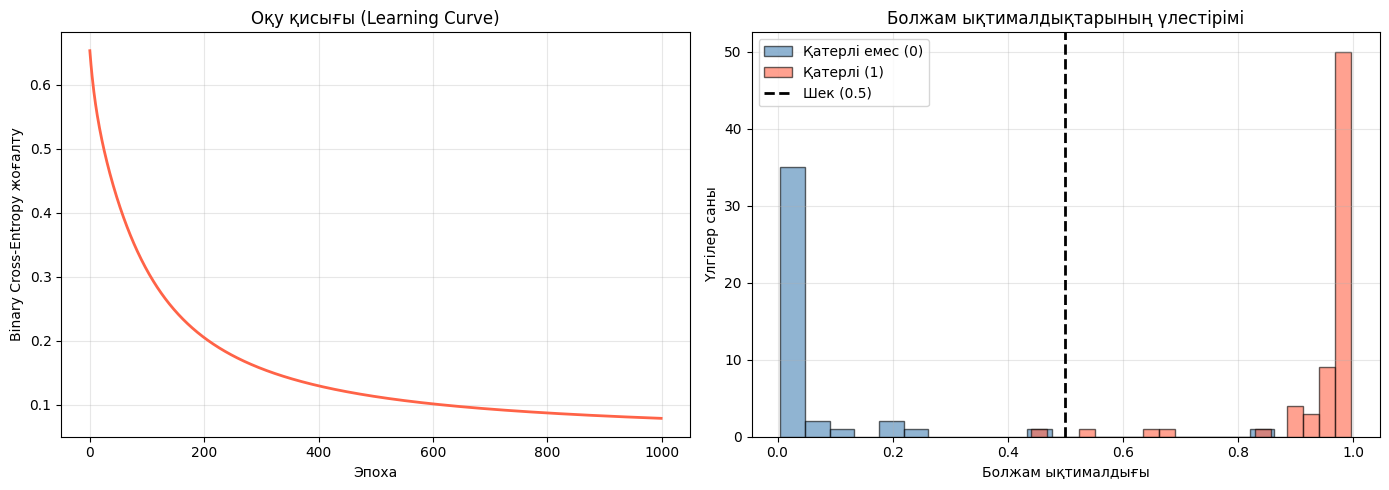


Жіктеу есебі:
              precision    recall  f1-score   support

Қатерлі емес       0.98      0.98      0.98        43
     Қатерлі       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [30]:
# Оқу динамикасын визуализациялаймыз

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Жоғалту қисығы
axes[0].plot(net.loss_history, color='tomato', linewidth=2)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Binary Cross-Entropy жоғалту")
axes[0].set_title("Оқу қисығы (Learning Curve)")

# Болжам ықтималдықтарының үлестірімі
net.forward(X_test)
proba_test = net.A2.flatten()
y_test_flat = y_test.flatten().astype(int)

for cls, color, label in [(0, 'steelblue', 'Қатерлі емес (0)'), (1, 'tomato', 'Қатерлі (1)')]:
    axes[1].hist(proba_test[y_test_flat == cls], bins=20, alpha=0.6,
                color=color, label=label, edgecolor='black')

axes[1].axvline(x=0.5, color='black', linewidth=2, linestyle='--', label='Шек (0.5)')
axes[1].set_xlabel("Болжам ықтималдығы")
axes[1].set_ylabel("Үлгілер саны")
axes[1].set_title("Болжам ықтималдықтарының үлестірімі")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nЖіктеу есебі:")
print(classification_report(y_test.astype(int), y_test_pred,
                            target_names=['Қатерлі емес', 'Қатерлі']))



## Жағдайлық зерттеу 3 (Case Study 3) — Оқу жылдамдығының оқу қисығына әсері

**Мақсат:** Оқу жылдамдығының тым кіші немесе тым үлкен болуының жоғалту динамикасына қалай кері әсер ететінін визуалды зерттеу.

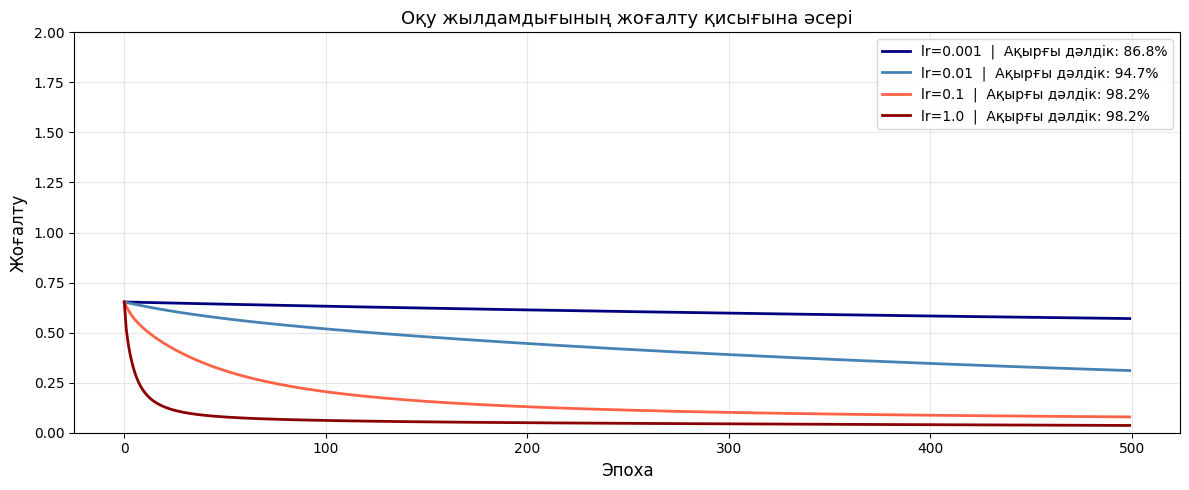


Талдау:
  lr=0.001 — тым баяу жинақталады (жеткілікті эпоха қажет)
  lr=0.01  — тепе-тең жинақталу
  lr=0.1   — жылдам, бірақ тұрақсыз болуы мүмкін
  lr=1.0   — тым үлкен: жоғалту өспелі немесе тербелмелі


In [31]:
# Case Study 3
learning_rates_test = [0.001, 0.01, 0.1, 1.0]
colors_lr = ['navy', 'steelblue', 'tomato', 'darkred']

plt.figure(figsize=(12, 5))

for lr, color in zip(learning_rates_test, colors_lr):
    net_lr = TwoLayerNet(n_input=30, n_hidden=16, n_output=1, lr=lr, seed=42)
    net_lr.train(X_train, y_train, n_epochs=500, verbose=False)

    final_pred = net_lr.predict(X_test)
    final_acc = accuracy_score(y_test.astype(int), final_pred)

    plt.plot(net_lr.loss_history, color=color, linewidth=2,
             label=f"lr={lr}  |  Ақырғы дәлдік: {final_acc*100:.1f}%")

plt.xlabel("Эпоха", fontsize=12)
plt.ylabel("Жоғалту", fontsize=12)
plt.title("Оқу жылдамдығының жоғалту қисығына әсері", fontsize=13)
plt.legend(fontsize=10)
plt.ylim(0, 2)
plt.tight_layout()
plt.show()

print("\nТалдау:")
print("  lr=0.001 — тым баяу жинақталады (жеткілікті эпоха қажет)")
print("  lr=0.01  — тепе-тең жинақталу")
print("  lr=0.1   — жылдам, бірақ тұрақсыз болуы мүмкін")
print("  lr=1.0   — тым үлкен: жоғалту өспелі немесе тербелмелі")

In [32]:
# Case Study 3 — Студент тапсырмасы
# TODO: Wine деректер жиынын жүктеп, 3 кластық жіктеуші оқытыңыз.
# sklearn MLPClassifier қолданыңыз, 3 түрлі learning_rate_init мәнін салыстырыңыз.
# Кеңес: MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, learning_rate_init=lr)

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

# TODO: X_wine нормализациялаңыз (StandardScaler)
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine_scaled, y_wine, test_size=0.2, random_state=42
)


lrs_wine = [0.001, 0.01, 0.1]
print("Wine деректері — MLP нәтижелері:")
print("-" * 40)

for lr_w in lrs_wine:
    clf = MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        learning_rate_init=lr_w,
        random_state=42
    )

    clf.fit(X_w_train, y_w_train)

    acc_w = accuracy_score(y_w_test, clf.predict(X_w_test))
    print(f"lr={lr_w}: дәлдік = {acc_w*100:.1f}%")

Wine деректері — MLP нәтижелері:
----------------------------------------
lr=0.001: дәлдік = 100.0%
lr=0.01: дәлдік = 100.0%
lr=0.1: дәлдік = 100.0%


### Тапсырма CS3-Б — Оқу жылдамдығы мен пакет өлшемін (batch size) салыстыру

**Мақсат:** sklearn MLPClassifier ішіндегі batch_size параметрінің оқу жылдамдығына (жинақталу уақытына) әсерін зерттеу.

In [36]:
# Тапсырма CS3-Б
# Iris деректерімен batch_size мәндерін салыстырамыз
# Кеңес: MLPClassifier(batch_size=...) параметрін қолданыңыз
# batch_size='auto' — sklearn өзі таңдайды
# batch_size=1 — SGD (стохастикалық)
# batch_size=len(X_i_train) — толық батч (GD)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Iris деректері
iris_full = load_iris()
X_iris_f = iris_full.data
y_iris_f = iris_full.target

# масштабтау
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris_f)

# дұрыс бөлу (осы жерде X_i_train пайда болады)
X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_iris_scaled,
    y_iris_f,
    test_size=0.25,
    random_state=42
)


In [37]:
batch_sizes = [1, 16, 'auto']

print(f"{'Batch size':<12} {'Итерация':>10} {'Тест дәлдігі':>14}")
print("-" * 40)

for bs in batch_sizes:
    clf_bs = MLPClassifier(
        hidden_layer_sizes=(16,),
        max_iter=500,
        learning_rate_init=0.01,
        batch_size=bs,
        random_state=42
    )

    clf_bs.fit(X_i_train, y_i_train)

    acc_bs = accuracy_score(y_i_test, clf_bs.predict(X_i_test))

    print(f"{str(bs):<12} {clf_bs.n_iter_:>10} {acc_bs*100:>13.1f}%")

Batch size     Итерация   Тест дәлдігі
----------------------------------------
1                    32          97.4%
16                   77         100.0%
auto                179         100.0%




## Жағдайлық зерттеу 4 (Case Study 4) — Желі тереңдігінің дәлдікке әсері

**Мақсат:** Жасырын қабат санының (1, 2, 3 қабат) жіктеу дәлдігіне қалай әсер ететінін Iris деректерінде тексеру.

**Деректер:** Iris (3 класс, 4 белгі) — sklearn кірістірілген деректер жиыны.

Желі тереңдігін салыстыру (Iris деректері):
-------------------------------------------------------
  (10,)                | Оқу: 98.2% | Тест: 100.0%
  (16, 8)              | Оқу: 98.2% | Тест: 100.0%
  (32, 16, 8)          | Оқу: 100.0% | Тест: 97.4%
  (64, 32, 16, 8)      | Оқу: 100.0% | Тест: 97.4%


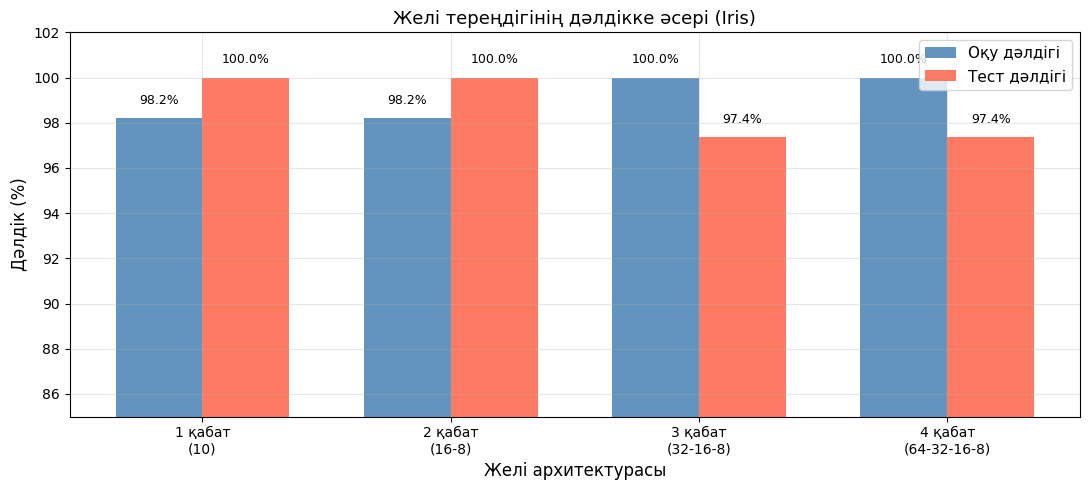

In [38]:
# Case Study 4
iris_full = load_iris()
X_iris_f = iris_full.data
y_iris_f = iris_full.target

scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris_f)

X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_iris_scaled, y_iris_f, test_size=0.25, random_state=42
)

# Желі архитектуралары
architectures = [
    (10,),           # 1 жасырын қабат
    (16, 8),         # 2 жасырын қабат
    (32, 16, 8),     # 3 жасырын қабат
    (64, 32, 16, 8), # 4 жасырын қабат
]

arch_names = ['1 қабат\n(10)', '2 қабат\n(16-8)', '3 қабат\n(32-16-8)', '4 қабат\n(64-32-16-8)']
train_accs, test_accs = [], []

print("Желі тереңдігін салыстыру (Iris деректері):")
print("-" * 55)

for arch, name_arch in zip(architectures, arch_names):
    clf_arch = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000,
                             learning_rate_init=0.01, random_state=42,
                             activation='relu')
    clf_arch.fit(X_i_train, y_i_train)

    train_acc = accuracy_score(y_i_train, clf_arch.predict(X_i_train))
    test_acc = accuracy_score(y_i_test, clf_arch.predict(X_i_test))
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"  {str(arch):20s} | Оқу: {train_acc*100:.1f}% | Тест: {test_acc*100:.1f}%")

# Визуализация
x_pos = np.arange(len(architectures))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x_pos - width/2, [a*100 for a in train_accs], width,
               label='Оқу дәлдігі', color='steelblue', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, [a*100 for a in test_accs], width,
               label='Тест дәлдігі', color='tomato', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Желі архитектурасы", fontsize=12)
ax.set_ylabel("Дәлдік (%)", fontsize=12)
ax.set_title("Желі тереңдігінің дәлдікке әсері (Iris)", fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(arch_names, fontsize=10)
ax.set_ylim(85, 102)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Breast Cancer — Желі тереңдігін салыстыру
--------------------------------------------------
(16,) | Train: 100.00% | Test: 93.86%
(32, 16) | Train: 100.00% | Test: 95.61%
(64, 32, 16) | Train: 100.00% | Test: 96.49%


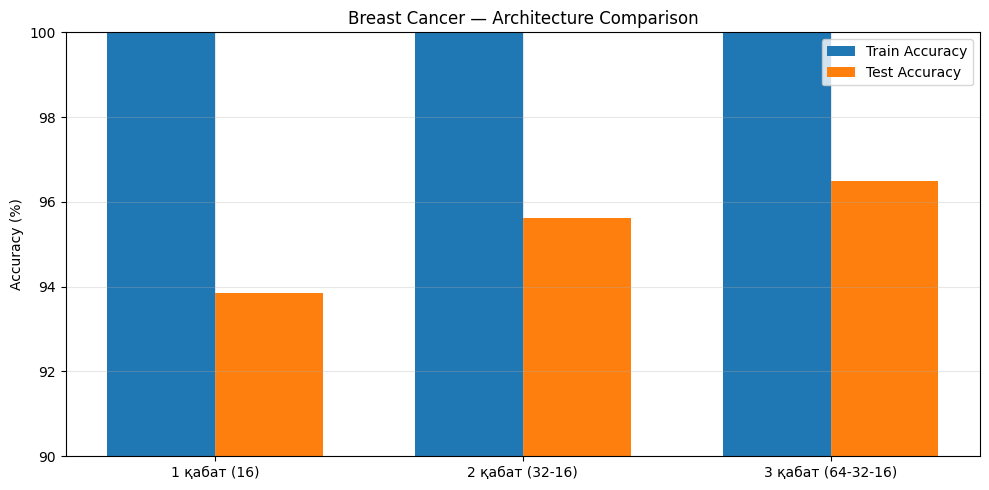

In [42]:
# Case Study 4 — Breast Cancer архитектураларын салыстыру
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target


scaler = StandardScaler()
X_cancer_scaled = scaler.fit_transform(X_cancer)


X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_cancer_scaled,
    y_cancer,
    test_size=0.2,
    random_state=42,
    stratify=y_cancer
)


architectures_bc = [
    (16,),
    (32, 16),
    (64, 32, 16)
]

arch_names = [
    "1 қабат (16)",
    "2 қабат (32-16)",
    "3 қабат (64-32-16)"
]

train_accs = []
test_accs = []

print("Breast Cancer — Желі тереңдігін салыстыру")
print("-" * 50)


for arch in architectures_bc:
    clf = MLPClassifier(
        hidden_layer_sizes=arch,
        max_iter=1000,
        learning_rate_init=0.01,
        random_state=42
    )

    clf.fit(X_c_train, y_c_train)

    train_acc = accuracy_score(y_c_train, clf.predict(X_c_train))
    test_acc = accuracy_score(y_c_test, clf.predict(X_c_test))

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"{arch} | Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}%")


x = np.arange(len(architectures_bc))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, [a*100 for a in train_accs], width, label="Train Accuracy")
plt.bar(x + width/2, [a*100 for a in test_accs], width, label="Test Accuracy")

plt.xticks(x, arch_names)
plt.ylabel("Accuracy (%)")
plt.title("Breast Cancer — Architecture Comparison")
plt.legend()
plt.ylim(90, 100)

plt.tight_layout()
plt.show()

### Тапсырма CS4-Б — Overfitting-ті анықтау

**Мақсат:** Оқу және тест дәлдіктерінің айырмасы арқылы артық оқуды (overfitting) анықтап, қай архитектурада ол байқалатынын көрсету.

In [43]:
# Тапсырма CS4-Б
# CS4 нәтижелерін (train_accs, test_accs) қолданыңыз
# Overfitting = train_acc >> test_acc

# TODO: Әрбір архитектура үшін (train_acc - test_acc) айырмасын есептеңіз
# Кеңес: train_accs және test_accs тізімдері CS4 ұяшығында анықталған

print("Overfitting талдауы (Iris деректері):")
print(f"{'Архитектура':<25} {'Айырма (train-test)':>20}")
print("-" * 48)

for arch_name, tr, te in zip(arch_names, train_accs, test_accs):
    # TODO: Айырманы есептеп, % түрінде басып шығарыңыз
    diff = tr - te
    status = "OVERFITTING" if diff > 0.05 else "OK"
    print(f"{arch_name.replace(chr(10),' '):<25} {diff*100:>15.1f}%  {status}")


Overfitting талдауы (Iris деректері):
Архитектура                Айырма (train-test)
------------------------------------------------
1 қабат (16)                          6.1%  OVERFITTING
2 қабат (32-16)                       4.4%  OK
3 қабат (64-32-16)                    3.5%  OK




## Жағдайлық зерттеу 5 (Case Study 5) — Активация функцияларын салыстыру

**Мақсат:** ReLU, Tanh, Sigmoid, Logistic активация функцияларының бір деректер жиынындағы жіктеу нәтижелерін жүйелі түрде салыстыру.

**Деректер:** Wine Quality (sklearn load_wine) — 3 класс, 13 белгі.

Активация функцияларын салыстыру (Wine деректері):
-------------------------------------------------------
  relu       | Оқу: 100.0% | Тест: 100.0% | Итерация: 40
  tanh       | Оқу: 100.0% | Тест: 100.0% | Итерация: 45
  logistic   | Оқу: 100.0% | Тест: 100.0% | Итерация: 100


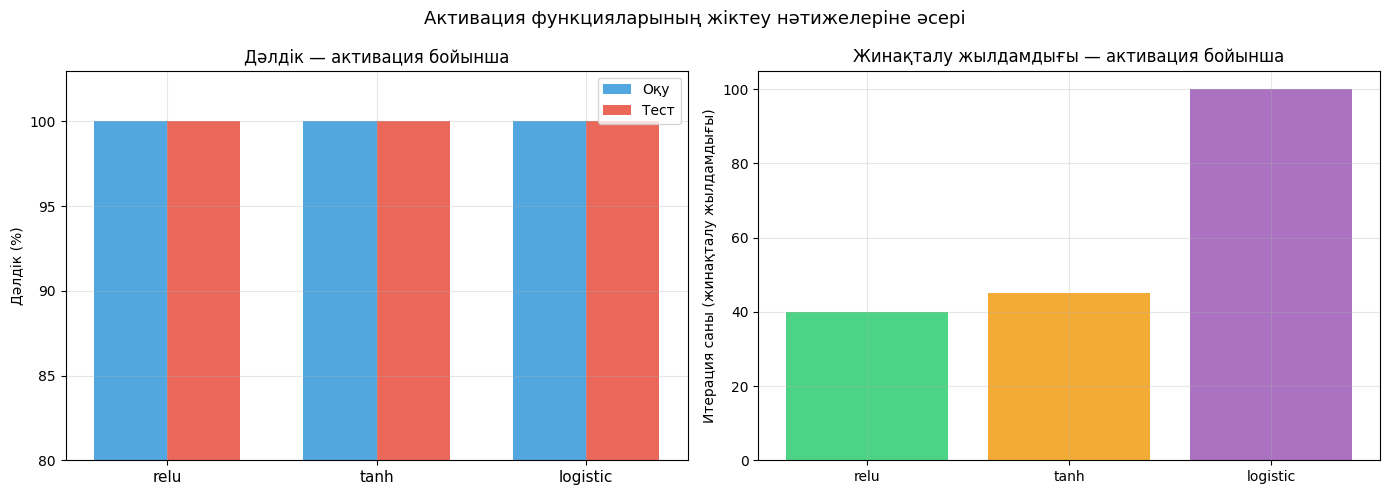

In [44]:
# Case Study 5
wine_data = load_wine()
X_w5 = wine_data.data
y_w5 = wine_data.target

scaler_w5 = StandardScaler()
X_w5_scaled = scaler_w5.fit_transform(X_w5)

X_w5_train, X_w5_test, y_w5_train, y_w5_test = train_test_split(
    X_w5_scaled, y_w5, test_size=0.2, random_state=42
)

activation_funcs = ['relu', 'tanh', 'logistic']
act_results = {}

print("Активация функцияларын салыстыру (Wine деректері):")
print("-" * 55)

for act in activation_funcs:
    clf_act = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        max_iter=2000,
        learning_rate_init=0.01,
        random_state=42
    )
    clf_act.fit(X_w5_train, y_w5_train)

    train_acc = accuracy_score(y_w5_train, clf_act.predict(X_w5_train))
    test_acc = accuracy_score(y_w5_test, clf_act.predict(X_w5_test))
    n_iter = clf_act.n_iter_
    act_results[act] = {'train': train_acc, 'test': test_acc, 'iters': n_iter}

    print(f"  {act:10s} | Оқу: {train_acc*100:.1f}% | Тест: {test_acc*100:.1f}% | Итерация: {n_iter}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names_act = list(act_results.keys())
train_vals = [act_results[a]['train'] * 100 for a in names_act]
test_vals  = [act_results[a]['test'] * 100 for a in names_act]
iters_vals = [act_results[a]['iters'] for a in names_act]

x_act = np.arange(len(names_act))
w_act = 0.35

axes[0].bar(x_act - w_act/2, train_vals, w_act, label='Оқу', color='#3498db', alpha=0.85)
axes[0].bar(x_act + w_act/2, test_vals, w_act, label='Тест', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x_act)
axes[0].set_xticklabels(names_act, fontsize=11)
axes[0].set_ylabel("Дәлдік (%)")
axes[0].set_title("Дәлдік — активация бойынша")
axes[0].set_ylim(80, 103)
axes[0].legend()

axes[1].bar(names_act, iters_vals, color=['#2ecc71', '#f39c12', '#9b59b6'], alpha=0.85)
axes[1].set_ylabel("Итерация саны (жинақталу жылдамдығы)")
axes[1].set_title("Жинақталу жылдамдығы — активация бойынша")

plt.suptitle("Активация функцияларының жіктеу нәтижелеріне әсері", fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
# Case Study 5 — Студент тапсырмасы
# TODO: Iris деректерінде де активация функцияларын салыстырыңыз.
# Жасырын қабат: (32, 16)
# Активациялар: 'relu', 'tanh', 'logistic'
# Оқу жылдамдығы: 0.01
# Нәтижелерді кестеде немесе диаграммада ұсыныңыз.

# Кеңес: жоғарыдағы Case Study 5 кодын шаблон ретінде алыңыз.
# X_iris_scaled, y_iris_f мәліметтерін қолданыңыз.

# TODO: Кодыңызды мына жерден жазыңыз
iris_full = load_iris()
X_iris = iris_full.data
y_iris = iris_full.target

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris_scaled, y_iris, test_size=0.25, random_state=42
)

for act in ['relu', 'tanh', 'logistic']:
    clf = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation=act,
        max_iter=1000,
        learning_rate_init=0.01,
        random_state=42
    )

    clf.fit(X_tr, y_tr)

    acc = accuracy_score(y_te, clf.predict(X_te))
    print(f"{act}: {acc*100:.1f}%")

relu: 100.0%
tanh: 100.0%
logistic: 100.0%


### Тапсырма CS5-Б — Sklearn classification_report талдауы

**Мақсат:** Wine деректерінің тест жиынында ең жақсы нәтиже берген активация функциясы үшін толық classification_report шығарып, precision, recall, f1-score мәндерін талдау.

In [46]:
# Тапсырма CS5-Б
# Кеңес: CS5 нәтижелерінен ең жоғары тест дәлдігі бар активацияны таңдаңыз
# Содан кейін сол модельді қайта оқытып, classification_report шығарыңыз

# TODO: Ең жақсы активация функциясын анықтаңыз
best_act = max(act_results, key=lambda k: act_results[k]['test'])

# TODO: Сол активациямен MLPClassifier жасаңыз
clf_best = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation=best_act,
    max_iter=2000,
    learning_rate_init=0.01,
    random_state=42
)

clf_best.fit(X_w5_train, y_w5_train)

y_best_pred = clf_best.predict(X_w5_test)

print(classification_report(
    y_w5_test,
    y_best_pred,
    target_names=wine_data.target_names
))


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Тапсырма CS5-В — Aktivация функцияларын итерация санымен салыстыру

**Мақсат:** Ең аз итерациямен жинақталған активация функциясын анықтап, тиімділікті бағалау.

In [47]:
fastest_act = min(act_results, key=lambda k: act_results[k]['iters'])
print(f"Ең жылдам жинақталған активация: {fastest_act}")
print(f"Итерация саны: {act_results[fastest_act]['iters']}")

best_acc_act = max(act_results, key=lambda k: act_results[k]['test'])
print(f"\nЕң жоғары тест дәлдігі: {best_acc_act}")
print(f"Дәлдік: {act_results[best_acc_act]['test']*100:.1f}%")

Ең жылдам жинақталған активация: relu
Итерация саны: 40

Ең жоғары тест дәлдігі: relu
Дәлдік: 100.0%




## Жағдайлық зерттеу 6 (Case Study 6) — Толық жоба: Breast Cancer диагностикасы

**Мақсат:** Барлық меңгерілген ұғымдарды біріктіріп, нуль деңгейден толыққанды классификация жүйесін жобалау, оқыту, бағалау және нәтижелерін интерпретациялау.

**Деректер:** Breast Cancer Wisconsin (sklearn кірістірілген) — 569 үлгі, 30 белгі, 2 класс.

**Студент міндеттері:** Берілген скелетті толтырып, толық жобаны аяқтаңыз.

Breast Cancer деректер жиыны туралы ақпарат:
  Үлгілер саны: 569
  Белгілер саны: 30
  Класс атаулары: ['malignant' 'benign']
  Класс 0 (malignant): 212 үлгі
  Класс 1 (benign):    357 үлгі


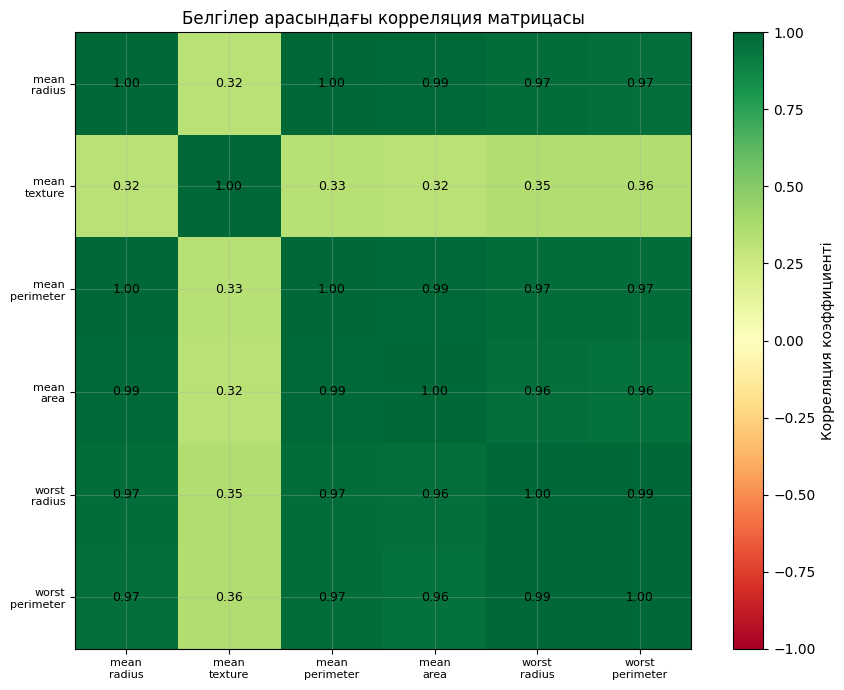

In [48]:
# Case Study 6 — Бөлім А: Деректерді зерттеу (EDA)

cancer_data = load_breast_cancer()
X_c6 = cancer_data.data
y_c6 = cancer_data.target

print("Breast Cancer деректер жиыны туралы ақпарат:")
print(f"  Үлгілер саны: {X_c6.shape[0]}")
print(f"  Белгілер саны: {X_c6.shape[1]}")
print(f"  Класс атаулары: {cancer_data.target_names}")
print(f"  Класс 0 (malignant): {(y_c6 == 0).sum()} үлгі")
print(f"  Класс 1 (benign):    {(y_c6 == 1).sum()} үлгі")

# Ең маңызды 6 белгінің корреляция матрицасы
feature_indices = [0, 1, 2, 3, 20, 22]  # Ең маңызды белгілер
feature_names_short = [cancer_data.feature_names[i] for i in feature_indices]

X_subset = X_c6[:, feature_indices]
corr_matrix = np.corrcoef(X_subset.T)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Корреляция коэффициенті')
ax.set_xticks(range(len(feature_names_short)))
ax.set_yticks(range(len(feature_names_short)))
ax.set_xticklabels([f.replace(' ', '\n') for f in feature_names_short], fontsize=8)
ax.set_yticklabels([f.replace(' ', '\n') for f in feature_names_short], fontsize=8)
for i in range(len(feature_names_short)):
    for j in range(len(feature_names_short)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title("Белгілер арасындағы корреляция матрицасы", fontsize=12)
plt.tight_layout()
plt.show()

In [49]:
# Case Study 6 — Бөлім Б: Модельді оқыту

# TODO: Деректерді нормализациялаңыз
scaler_c6 = StandardScaler()
X_c6_scaled = scaler_c6.fit_transform(X_c6)

# TODO: train_test_split орындаңыз (test_size=0.2, random_state=42, stratify=y_c6)
X_c6_train, X_c6_test, y_c6_train, y_c6_test = train_test_split(
    X_c6_scaled,
    y_c6,
    test_size=0.2,
    random_state=42,
    stratify=y_c6
)

# Модель
clf_c6 = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=1000,
    learning_rate_init=0.001,
    random_state=42
)

# Оқыту
clf_c6.fit(X_c6_train, y_c6_train)

print("Модель оқытылды.")

Модель оқытылды.


Тест дәлдігі: 96.49%
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



NameError: name 'confusion_matrix' is not defined

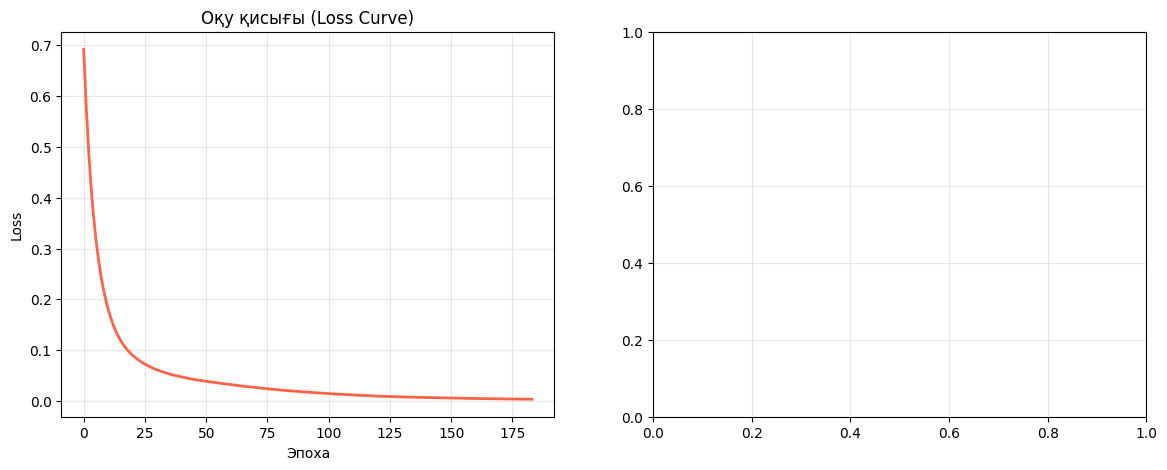

In [50]:
# Case Study 6 — Бөлім В: Бағалау және интерпретация

# TODO: Тест жиынында болжам жасаңыз
y_c6_pred = clf_c6.predict(X_c6_test)

# TODO: Дәлдікті есептеңіз
acc_c6 =  accuracy_score(y_c6_test, y_c6_pred)
print(f"Тест дәлдігі: {acc_c6 * 100:.2f}%")

# TODO: classification_report басып шығарыңыз
# print(classification_report(...))
print(classification_report(y_c6_test, y_c6_pred))
# TODO: Оқу қисығын салыңыз (clf_c6.loss_curve_)
# Кеңес: MLPClassifier-дің loss_curve_ атрибуты оқу кезіндегі жоғалту тарихын сақтайды
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: axes[0]-ге оқу қисығын салыңыз
axes[0].plot(clf_c6.loss_curve_, color='tomato', linewidth=2)
axes[0].set_title("Оқу қисығы (Loss Curve)")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")

# TODO: axes[1]-ге шатасу матрицасын (confusion matrix) салыңыз
cm = confusion_matrix(y_c6_test, y_c6_pred)

im = axes[1].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[1])

axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Болжам")
axes[1].set_ylabel("Нақты")

# мәндерді жазу
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, cm[i, j],
                     ha='center', va='center',
                     color='black', fontsize=12)

plt.tight_layout()
plt.show()

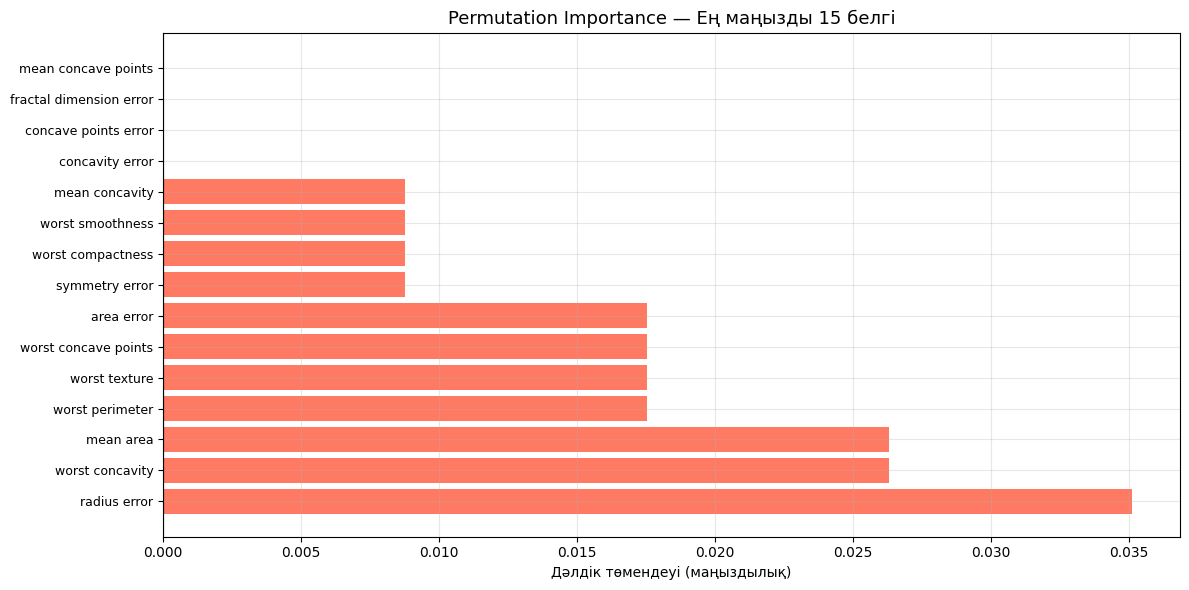


Ең маңызды белгі: radius error
Ең аз маңызды белгі: mean concave points


In [51]:
# Case Study 6 — Бөлім Г: Белгілер маңыздылығы
# Permutation importance арқылы белгілер маңыздылығын бағалаймыз

# Кеңес: Бұл кезек кіруге (permutation) негізделген қарапайым тәсіл.
# Әрбір белгіні кезекпен ысырып (shuffle), дәлдіктің қандай өзгеретінін өлшейміз.

baseline_acc = accuracy_score(y_c6_test, clf_c6.predict(X_c6_test))
importances = []

for feat_idx in range(X_c6_test.shape[1]):
    X_permuted = X_c6_test.copy()
    X_permuted[:, feat_idx] = np.random.permutation(X_permuted[:, feat_idx])
    permuted_acc = accuracy_score(y_c6_test, clf_c6.predict(X_permuted))
    importances.append(baseline_acc - permuted_acc)

importances = np.array(importances)
sorted_idx = np.argsort(importances)[::-1][:15]  # Ең маңызды 15 белгі

fig, ax = plt.subplots(figsize=(12, 6))
colors_imp = ['tomato' if v > 0 else 'steelblue' for v in importances[sorted_idx]]
ax.barh(range(15), importances[sorted_idx], color=colors_imp, alpha=0.85)
ax.set_yticks(range(15))
ax.set_yticklabels([cancer_data.feature_names[i] for i in sorted_idx], fontsize=9)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel("Дәлдік төмендеуі (маңыздылық)")
ax.set_title("Permutation Importance — Ең маңызды 15 белгі", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nЕң маңызды белгі: {cancer_data.feature_names[sorted_idx[0]]}")
print(f"Ең аз маңызды белгі: {cancer_data.feature_names[sorted_idx[-1]]}")

### Тапсырма CS6-Д — Гиперпараметрлерді іздеу (Manual Grid Search)

**Мақсат:** Жасырын қабат өлшемі мен оқу жылдамдығының комбинацияларынан ең жақсы нәтиже беретінін қолмен іздеу.

In [53]:
# Тапсырма CS6-Д
# Breast Cancer деректерінде қолмен grid search жүргіземіз
# Кеңес: 2 кіші цикл: hidden_sizes x learning_rates

hidden_options = [(16,), (32, 16), (64, 32)]
lr_options = [0.001, 0.01, 0.1]

best_score = 0
best_params = {}

print(f"{'Архитектура':<15} {'lr':>6} {'Тест дәлдігі':>14}")
print("-" * 38)

for h_size in hidden_options:
    for lr_gs in lr_options:

        clf_gs = MLPClassifier(
            hidden_layer_sizes=h_size,
            learning_rate_init=lr_gs,
            max_iter=500,
            random_state=42
        )

        clf_gs.fit(X_c6_train, y_c6_train)

        score_gs = accuracy_score(y_c6_test, clf_gs.predict(X_c6_test))

        print(f"{str(h_size):<15} {lr_gs:>6} {score_gs*100:>13.1f}%")

        if score_gs > best_score:
            best_score = score_gs
            best_params = {'hidden': h_size, 'lr': lr_gs}

print(f"\nЕң жақсы параметрлер: {best_params}")
print(f"Ең жоғары дәлдік: {best_score*100:.2f}%")


Архитектура         lr   Тест дәлдігі
--------------------------------------
(16,)            0.001          96.5%
(16,)             0.01          93.9%
(16,)              0.1          95.6%
(32, 16)         0.001          95.6%
(32, 16)          0.01          95.6%
(32, 16)           0.1          95.6%
(64, 32)         0.001          96.5%
(64, 32)          0.01          96.5%
(64, 32)           0.1          93.9%

Ең жақсы параметрлер: {'hidden': (16,), 'lr': 0.001}
Ең жоғары дәлдік: 96.49%


### Тапсырма CS6-Е — Қателікті талдау (Error Analysis)

**Мақсат:** Модель дұрыс жіктемеген үлгілерді (false positives, false negatives) анықтап, олардың белгілерін зерттеу.

In [54]:
# Тапсырма CS6-Е
# clf_c6 моделін қолданамыз (CS6 Бөлім Б-де оқытылған)

# TODO: y_c6_pred болжамдарын алыңыз (CS6 Бөлім В-де анықталған)
# Егер жоғарыда орындалмаса, мына жолды іске қосыңыз:
y_c6_pred = clf_c6.predict(X_c6_test)

# TODO: Қателіктер маскасын жасаңыз
error_mask = (y_c6_pred != y_c6_test)


print(f"Жалпы тест үлгілері: {len(y_c6_test)}")
print(f"Қателіктер саны:     {error_mask.sum()}")
print(f"Дәлдік:              {(1 - error_mask.mean())*100:.2f}%")

# TODO: False Positive және False Negative санын есептеңіз
# FP: y_c6_test=0 болса да модель 1 деп болжады
# FN: y_c6_test=1 болса да модель 0 деп болжады
fp_mask = (y_c6_pred == 1) & (y_c6_test == 0)
fn_mask = (y_c6_pred == 0) & (y_c6_test == 1)

print(f"\nFalse Positive (қатерлі еместі қатерлі деп): {fp_mask.sum()}")
print(f"False Negative (қатерліні өткізіп алу): {fn_mask.sum()}")

print("\nМедицинада False Negative ең қауіпті қате болып саналады.")


Жалпы тест үлгілері: 114
Қателіктер саны:     4
Дәлдік:              96.49%

False Positive (қатерлі еместі қатерлі деп): 1
False Negative (қатерліні өткізіп алу): 3

Медицинада False Negative ең қауіпті қате болып саналады.




# Қорытынды және өзін-өзі бағалау

Осы ноутбукты аяқтағаннан кейін, сіз мына ұғымдарды меңгердіңіз:

| Тақырып | Меңгерілген ұғым |
|---------|------------------|
| Нейрон | Өлшенген қосынды, bias, активация |
| Персептрон | Оқу ережесі, сызықты ажырату шектеулігі |
| Активация функциялары | Sigmoid, Tanh, ReLU, Softmax және олардың туындылары |
| MLP архитектурасы | Қабаттар, параметр саны |
| Тура таралу | Матрицалық есеп, жоғалту функциясы |
| Кері таралу | Тізбекті ереже, градиент түсу |

---

## Өзін-өзі бағалау сұрақтары

Мына сұрақтарға жауап беріп көріңіз (ноутбукты жаппай):

1. Персептрон XOR есебін неліктен шеше алмайды?
2. ReLU функциясының Sigmoid-пен салыстырғандағы артықшылығы қандай?
3. Оқу жылдамдығы тым үлкен болса не болады?
4. Кері таралу алгоритмінде «тізбекті ереже» қандай рөл атқарады?
5. «Жоғалатын градиент» (vanishing gradient) проблемасы неліктен туындайды?


## Пайдаланылған ресурстар

Осы тақырыпты тереңірек зерттеу үшін мына ресурстарды қарауға болады:

- **Кітап:** Aurélien Géron — «Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow» (2-ші басылым)
- **Kurs:** Andrew Ng — Deep Learning Specialization (Coursera)
- **Сайт:** cs231n.stanford.edu — Convolutional Neural Networks for Visual Recognition
- **Кітапхана:** scikit-learn.org — sklearn.neural_network.MLPClassifier құжаттамасы